# Data Exploration & EDA
## California Property Close Price Prediction

This notebook contains exploratory data analysis (EDA) for the CRMLS sold listings dataset. We'll examine distributions, patterns, key fields, and data quality to inform preprocessing and modeling decisions.

**Project:** IDX Exchange — Summer 2026 Data Science Internship  
**Target Variable:** `ClosePrice` (final sale price)  
**Dataset:** Single-family residential properties in California

---
##  Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
from pathlib import Path

# Point this to wherever you stored the CRMLSSold CSVs locally
DATA_DIR = Path.home()

FILE_MONTHS = [
    'CRMLSSold202511.csv',   # November 2025
    'CRMLSSold202512.csv',   # December 2025
    'CRMLSSold202601.csv',   # January 2026
    'CRMLSSold202602.csv',   # February 2026
    'CRMLSSold202603.csv',   # March 2026
    'CRMLSSold202604.csv',   # April 2026
    'CRMLSSold202605.csv',   # May 2026  ← held-out test set (Week 3)
]

frames = []
for fname in FILE_MONTHS:
    df_month = pd.read_csv(DATA_DIR / fname, low_memory=False)
    df_month['_source_file'] = fname
    frames.append(df_month)

raw = pd.concat(frames, ignore_index=True)

df = raw[
    (raw['PropertyType'] == 'Residential') &
    (raw['PropertySubType'] == 'SingleFamilyResidence')
].copy()

print(f'Loaded: {len(raw):,} total rows → {len(df):,} SFR rows')

Loaded: 143,492 total rows → 71,466 SFR rows


In [3]:
print(f'Rows after SFR filter : {len(df):,}')
print(f'Rows dropped (non-SFR): {len(raw) - len(df):,}')
print(f'SFR share of total    : {len(df)/len(raw)*100:.1f}%')

Rows after SFR filter : 71,466
Rows dropped (non-SFR): 72,026
SFR share of total    : 49.8%


In [4]:
# All remaining MlsStatus values should be 'Closed' — confirm
# Trestle: MlsStatus (MlsStatus Enum) — maps to StandardStatusprint('MlsStatus distribution in SFR set:')
print(df['MlsStatus'].value_counts())

MlsStatus
Closed    71466
Name: count, dtype: int64


In [5]:
raw.head(5)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,_source_file
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,5913.0,3.0,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN,CRMLSSold202511.csv
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,18432.0,NaN,False,2.0,Other,95124,NaN,18432.0,NaN,CRMLSSold202511.csv
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,5300.0,0.0,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN,CRMLSSold202511.csv
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,5272.0,1.0,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN,CRMLSSold202511.csv
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,10500.0,3.0,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN,CRMLSSold202511.csv


In [6]:
df.head(5)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,_source_file
0,OrangeCounty,OrangeCounty,"Carpet,Tile",False,NaN,NaN,False,1250000.0,1147233684,mattkanoudi@gmail.com,...,5913.0,3.0,False,2.0,Huntington Beach Union High,92646,0.0,5913.0,NaN,CRMLSSold202511.csv
1,Mlslistings,Mlslistings,Carpet,False,NaN,NaN,NaN,NaN,1147228247,babeksells@gmail.com,...,18432.0,NaN,False,2.0,Other,95124,NaN,18432.0,NaN,CRMLSSold202511.csv
2,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,799900.0,1147223143,rigosd@gmail.com,...,5300.0,0.0,NaN,2.0,San Diego Unified,92173,0.0,5300.0,NaN,CRMLSSold202511.csv
3,PacificSouthwest,PacificSouthwest,NaN,False,NaN,NaN,False,925000.0,1147209231,conchita@conchitalopez.com,...,5272.0,1.0,NaN,3.0,Sweetwater Union,92154,55.0,5272.0,NaN,CRMLSSold202511.csv
4,NorthSanLuisObispo,NorthSanLuisObispo,NaN,False,NaN,NaN,False,1300000.0,1147200364,dmvonderheide@gmail.com,...,10500.0,3.0,False,3.0,Templeton Unified,93465,0.0,10500.0,NaN,CRMLSSold202511.csv


In [7]:
df.describe()

,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,7.131400e+04,7.146600e+04,7.146600e+04,71457.000000,71457.000000,71432.000000,7.146600e+04,71466.000000,0.0,0.0,...,0.0,518.000000,0.0,63994.000000,7.024400e+04,43625.000000,68714.000000,51015.000000,7.023900e+04,0.0
mean,1.377403e+06,1.144602e+09,1.339923e+06,34.714612,-118.559103,2053.831846,1.265414e+06,41.758165,NaN,NaN,...,NaN,58.415058,NaN,1.352502,1.896649e+04,2.262877,2.006265,111.183889,4.813743e+05,NaN
std,8.346251e+06,1.358423e+07,7.387074e+06,1.788834,3.570638,1038.535401,1.512809e+06,56.980593,NaN,NaN,...,NaN,232.040664,NaN,0.477753,1.935028e+05,1.443249,3.465529,373.147289,2.122478e+07,NaN
min,0.000000e+00,4.217759e+08,1.750000e+00,-22.863239,-124.175789,0.000000,8.000000e+03,-265.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,6.299000e+05,1.138431e+09,6.200000e+05,33.755208,-119.074101,1387.000000,6.238925e+05,8.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.376000e+03,1.000000,2.000000,0.000000,5.663000e+03,NaN
50%,8.990000e+05,1.148842e+09,8.890000e+05,34.078986,-118.019069,1824.000000,8.890000e+05,20.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.020000e+03,3.000000,2.000000,0.000000,7.260000e+03,NaN
75%,1.430000e+06,1.153250e+09,1.420000e+06,34.701563,-117.252561,2451.000000,1.399000e+06,54.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,9.900000e+03,3.000000,2.000000,135.000000,1.045400e+04,NaN
max,1.302000e+09,1.171669e+09,7.960000e+08,43.784440,120.432670,31068.000000,6.500000e+07,2177.000000,NaN,NaN,...,NaN,2031.000000,NaN,2.000000,3.164242e+07,44.000000,600.000000,20712.000000,1.938943e+09,NaN


In [8]:
df.dtypes

BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
                                 ...   
PostalCode                       object
AssociationFee                  float64
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
_source_file                     object
Length: 79, dtype: object

### Parsing Date Time Fields

In [9]:
# Trestle DateTime fields (agent-entered contractual dates, not MLS timestamps):
#   CloseDate              — date purchase agreement was fulfilled
#   ListingContractDate    — effective date of seller/broker agreement
#   PurchaseContractDate   — date offer was accepted, listing went off market
#   ContractStatusChangeDate — date of contractual status change
DATE_COLS = ['CloseDate', 'ListingContractDate', 'PurchaseContractDate', 'ContractStatusChangeDate']
for col in DATE_COLS:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['CloseYear']      = df['CloseDate'].dt.year
df['CloseMonth']     = df['CloseDate'].dt.month
df['CloseYearMonth'] = df['CloseDate'].dt.to_period('M')

---
## 1. Field Audit — Null Rates & Usability

Before any analysis, we audit every Trestle field for null rates to decide what is usable for modelling.

In [10]:
# Full missing value audit across all 78 columns
missing = (
    df.isnull().sum()
    .to_frame('null_count')
    .assign(null_pct=lambda x: (x['null_count'] / len(df) * 100).round(1))
    .sort_values('null_pct', ascending=False)
)
print('Fields with any missing values:')
display(missing[missing['null_count'] > 0])

Fields with any missing values:


,null_count,null_pct
CoveredSpaces,71466,100.0
TaxAnnualAmount,71466,100.0
AboveGradeFinishedArea,71466,100.0
FireplacesTotal,71466,100.0
TaxYear,71466,100.0
...,...,...
ListAgentAOR,19,0.0
BathroomsTotalInteger,1,0.0
City,14,0.0
PurchaseContractDate,3,0.0


In [11]:
# Classify fields by usability based on null rates
# Fields at 100% null are effectively absent from this CRMLS data extract
FULLY_NULL = [col for col in df.columns if df[col].isna().all()]
print(f'Fields with 100% null values ({len(FULLY_NULL)} total — drop from modelling):')
for col in sorted(FULLY_NULL):
    print(f'  {col}')

# Note: AboveGradeFinishedArea, BelowGradeFinishedArea, BuildingAreaTotal,
# TaxAnnualAmount, CoveredSpaces, FireplacesTotal, BusinessType,
# ElementarySchoolDistrict, MiddleOrJuniorSchoolDistrict are all 100% null
# in this CRMLS extract — not available for modelling.

Fields with 100% null values (8 total — drop from modelling):
  AboveGradeFinishedArea
  BusinessType
  CoveredSpaces
  ElementarySchoolDistrict
  FireplacesTotal
  MiddleOrJuniorSchoolDistrict
  TaxAnnualAmount
  TaxYear


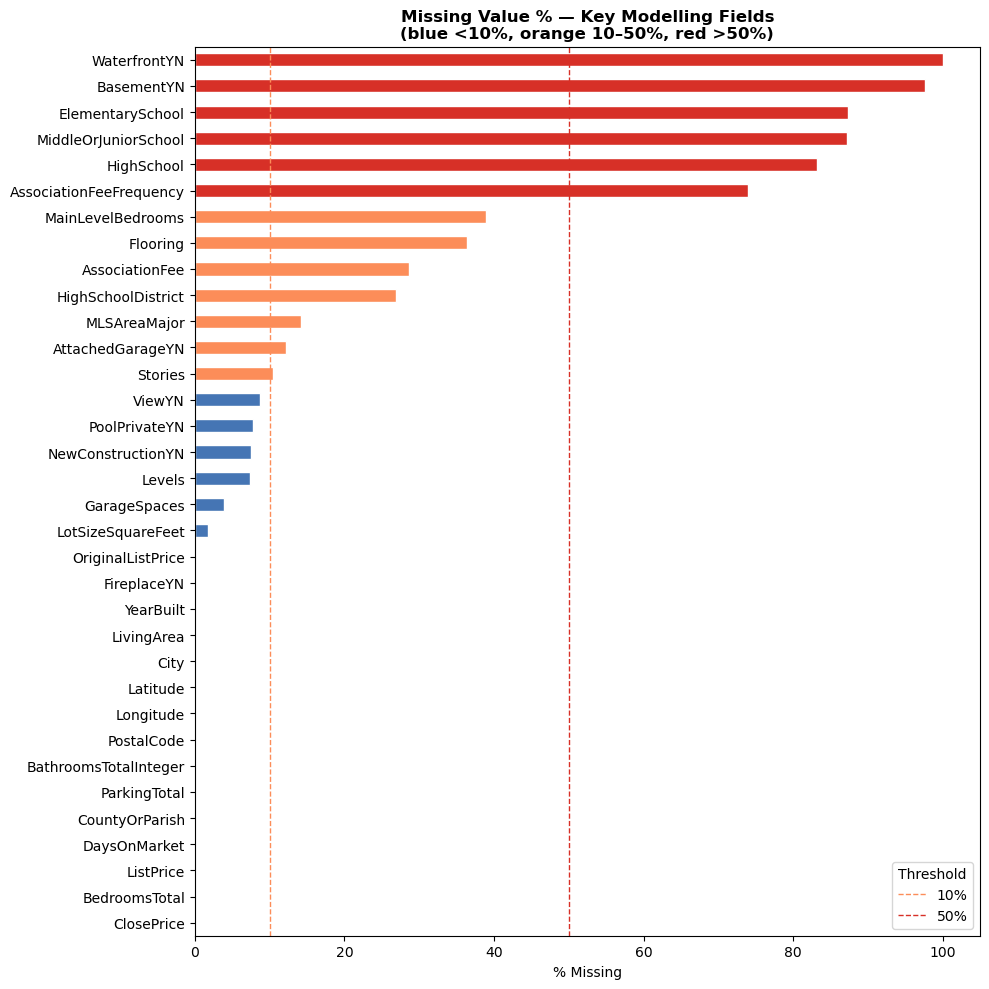

In [12]:
# Visual: missing % for the fields that ARE partially present
# Focus on key modelling candidates
KEY_COLS = [
    # Target
    'ClosePrice',
    # Core size (Trestle Decimal 14.2)
    'LivingArea', 'LotSizeSquareFeet',
    # Layout (Trestle Int32)
    'BedroomsTotal', 'BathroomsTotalInteger', 'Stories', 'MainLevelBedrooms',
    # Age
    'YearBuilt',
    # Pricing signal (Trestle Decimal 14.2)
    'ListPrice', 'OriginalListPrice',
    # Market timing (Trestle Int32)
    'DaysOnMarket',
    # Parking (Trestle Decimal 14.2)
    'GarageSpaces', 'ParkingTotal',
    # HOA (Trestle Decimal 14.2 / FeeFrequency Enum)
    'AssociationFee', 'AssociationFeeFrequency',
    # Boolean amenities
    'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'AttachedGarageYN',
    'NewConstructionYN', 'WaterfrontYN', 'BasementYN',
    # Geography (Trestle String / Decimal)
    'PostalCode', 'CountyOrParish', 'City', 'MLSAreaMajor',
    'Latitude', 'Longitude',
    # Schools (Trestle String 50)
    'HighSchoolDistrict', 'HighSchool',
    'MiddleOrJuniorSchool', 'ElementarySchool',
    # Categorical
    'Levels', 'Flooring',
]

miss_pct = df[KEY_COLS].isnull().mean().sort_values(ascending=True) * 100

fig, ax = plt.subplots(figsize=(10, 10))
colors = miss_pct.map(lambda x: '#d73027' if x > 50 else ('#fc8d59' if x > 10 else '#4575b4'))
miss_pct.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(10, color='#fc8d59', linestyle='--', linewidth=1, label='10%')
ax.axvline(50, color='#d73027', linestyle='--', linewidth=1, label='50%')
ax.set_title('Missing Value % — Key Modelling Fields\n(blue <10%, orange 10–50%, red >50%)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('% Missing')
ax.legend(title='Threshold')
plt.tight_layout()
plt.show()

In [13]:
# Summary table: modelling decision per field
field_decisions = {
    'LivingArea':            ('0.0%',  'Use as-is — total livable area (Decimal 14.2)'),
    'LotSizeSquareFeet':     ('1.7%',  'Impute with ZIP-level median — preferred over LotSizeAcres/LotSizeArea'),
    'BedroomsTotal':         ('0.0%',  'Use as-is — total bedrooms (Int32)'),
    'BathroomsTotalInteger': ('0.0%',  'Use as-is — simple sum of all bathrooms (Int32)'),
    'Stories':               ('10.5%', 'Impute with mode or group median — number of floors (Int32)'),
    'MainLevelBedrooms':     ('39.0%', 'High null rate — use cautiously or drop; may overlap with BedroomsTotal'),
    'YearBuilt':             ('0.1%',  'Engineer PropertyAge = 2026 - YearBuilt (Int32)'),
    'ListPrice':             ('0.0%',  'Use as-is — current asking price; high correlation with ClosePrice'),
    'OriginalListPrice':     ('0.2%',  'Engineer PriceReductionYN flag from ListPrice vs OriginalListPrice'),
    'DaysOnMarket':          ('0.0%',  'Use as-is — MLS-calculated DOM (Int32)'),
    'GarageSpaces':          ('3.9%',  'Impute 0 for NaN — number of garage spaces (Decimal 14.2)'),
    'ParkingTotal':          ('0.0%',  'Use as-is — total spaces including uncovered (Decimal 14.2)'),
    'AssociationFee':        ('28.6%', 'NaN likely means no HOA — impute 0; normalize using AssociationFeeFrequency'),
    'AssociationFeeFrequency':('74.0%','Use to normalize AssociationFee to monthly; NaN = no HOA'),
    'PoolPrivateYN':         ('7.8%',  'Impute False — privately owned pool included in sale (Boolean)'),
    'ViewYN':                ('8.7%',  'Impute False — property has a view (Boolean)'),
    'FireplaceYN':           ('0.1%',  'Use as-is — property includes a fireplace (Boolean)'),
    'AttachedGarageYN':      ('12.2%', 'Impute False — garage attached to main dwelling (Boolean)'),
    'NewConstructionYN':     ('7.6%',  'Impute False — newly constructed, not previously occupied (Boolean)'),
    'WaterfrontYN':          ('99.9%', 'DROP — nearly all null; 0.1% true in SFR dataset'),
    'BasementYN':            ('97.6%', 'DROP — nearly all null; basement uncommon in CA SFR'),
    'PostalCode':            ('0.0%',  'Use as categorical — 1,675 unique ZIPs (String 10)'),
    'CountyOrParish':        ('0.0%',  'Use as categorical — 60 counties (String 50)'),
    'City':                  ('0.0%',  'Use as categorical — 928 cities; high cardinality (String 50)'),
    'MLSAreaMajor':          ('14.2%', 'Use as categorical — 980 MLS-defined areas; high cardinality (String 50)'),
    'Latitude':              ('0.0%',  'Use for spatial join and geo features (Decimal 12.8)'),
    'Longitude':             ('0.0%',  'Use for spatial join and geo features (Decimal 12.8)'),
    'HighSchoolDistrict':    ('26.9%', 'Supplement with spatial join (Week 6) — preferred school district field'),
    'HighSchool':            ('83.2%', 'DROP — too sparse; HighSchoolDistrict preferred per Trestle guidance'),
    'MiddleOrJuniorSchool':  ('87.2%', 'DROP — too sparse'),
    'ElementarySchool':      ('87.3%', 'DROP — too sparse'),
    'Levels':                ('7.4%',  'Encode as ordinal — One/Two/ThreeOrMore/MultiSplit (Levels Enum)'),
    'Flooring':              ('36.3%', 'Multi-value enum — 235 combos; consider binary flags for top types'),
}

decisions_df = pd.DataFrame.from_dict(
    field_decisions, orient='index', columns=['null_pct', 'decision']
)
display(decisions_df)

,null_pct,decision
LivingArea,0.0%,Use as-is — total livable area (Decimal 14.2)
LotSizeSquareFeet,1.7%,Impute with ZIP-level median — preferred over ...
BedroomsTotal,0.0%,Use as-is — total bedrooms (Int32)
BathroomsTotalInteger,0.0%,Use as-is — simple sum of all bathrooms (Int32)
Stories,10.5%,Impute with mode or group median — number of f...
MainLevelBedrooms,39.0%,High null rate — use cautiously or drop; may o...
YearBuilt,0.1%,Engineer PropertyAge = 2026 - YearBuilt (Int32)
ListPrice,0.0%,Use as-is — current asking price; high correla...
OriginalListPrice,0.2%,Engineer PriceReductionYN flag from ListPrice ...
DaysOnMarket,0.0%,Use as-is — MLS-calculated DOM (Int32)


## Decision For Future Phases

---
## 2. Dataset Overview

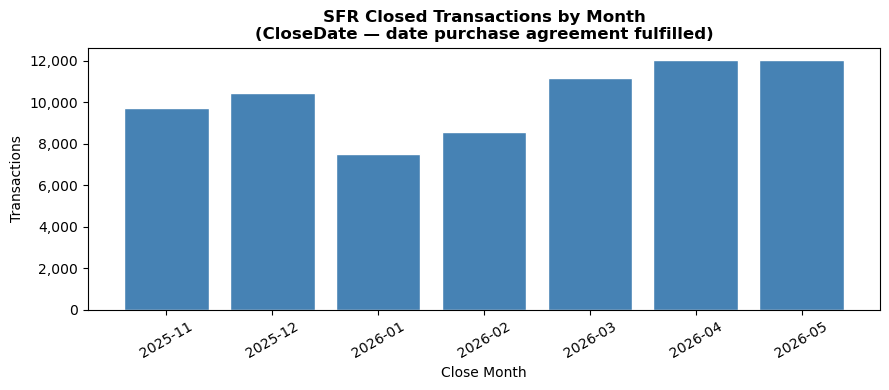

  Month  Transactions
2025-11          9739
2025-12         10455
2026-01          7490
2026-02          8550
2026-03         11177
2026-04         12031
2026-05         12024


In [14]:
# Monthly volume — using CloseDate (Trestle DateTime: date purchase agreement fulfilled)
monthly = df['CloseYearMonth'].value_counts().sort_index().reset_index()
monthly.columns = ['Month', 'Transactions']

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly['Month'].astype(str), monthly['Transactions'],
       color='steelblue', edgecolor='white')
ax.set_title('SFR Closed Transactions by Month\n(CloseDate — date purchase agreement fulfilled)',
             fontweight='bold')
ax.set_xlabel('Close Month')
ax.set_ylabel('Transactions')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(monthly.to_string(index=False))

In [15]:
# PropertySubType breakdown of ALL Residential records — confirms SFR dominance
# Trestle: PropertySubType (PropertySubType Enum)
subtype_counts = raw[raw['PropertyType']=='Residential']['PropertySubType'].value_counts()
print('Residential PropertySubType breakdown (full dataset):')
print(subtype_counts.to_string())

Residential PropertySubType breakdown (full dataset):
PropertySubType
SingleFamilyResidence    71466
Condominium              15748
Townhouse                 5618
ManufacturedOnLand        1261
Duplex                     579
StockCooperative           354
Cabin                      112
Triplex                    106
MixedUse                    64
Quadruplex                  43
MobileHome                  32
BoatSlip                    23
OwnYourOwn                  11
ManufacturedHome             8
Loft                         7
Studio                       3
CoOwnership                  3
Timeshare                    3
Farm                         2
DeededParking                1


---
## 3. Target Variable: ClosePrice

**Trestle definition:** `ClosePrice` (Decimal 14.2) — *The amount of money paid by the purchaser to the seller for the property under the agreement.*  
This is the true transaction value — distinct from `ListPrice` (seller's ask) and `OriginalListPrice` (initial ask).

In [16]:
# Summary statistics
print('ClosePrice summary statistics:')
display(
    df['ClosePrice']
    .describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
    .apply(lambda x: f'${x:,.0f}')
)

ClosePrice summary statistics:


count         $71,466
mean       $1,339,923
std        $7,387,074
min                $2
1%           $230,000
5%           $365,000
25%          $620,000
50%          $889,000
75%        $1,420,000
95%        $3,200,000
99%        $6,500,000
max      $796,000,000
Name: ClosePrice, dtype: object

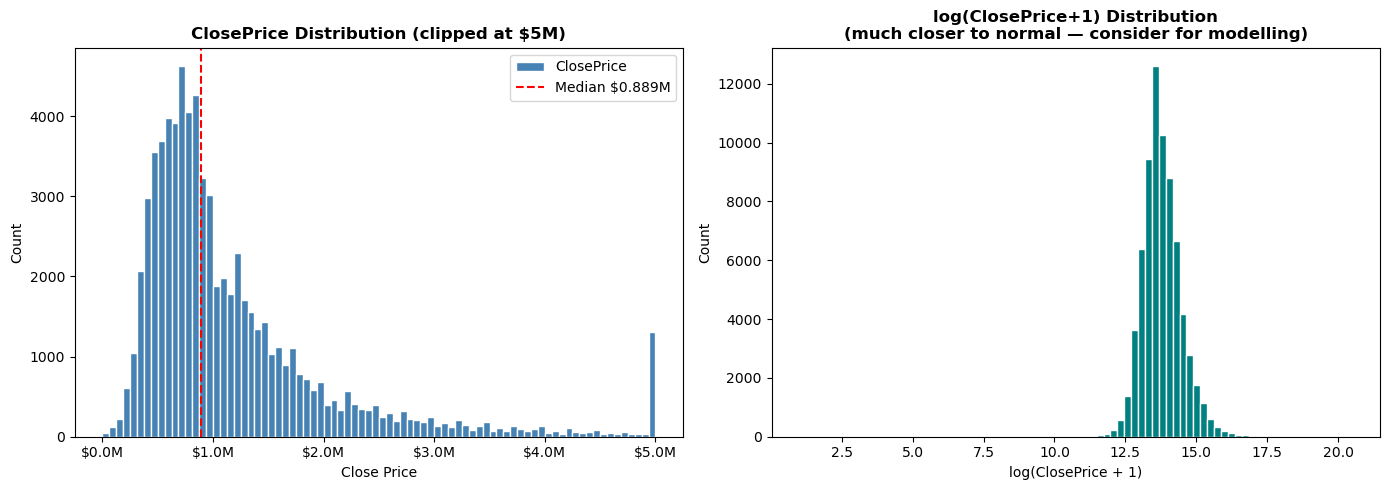

In [17]:
# Distribution: raw vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['ClosePrice'].clip(upper=5_000_000).plot(
    kind='hist', bins=80, ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].axvline(df['ClosePrice'].median(), color='red', linestyle='--',
                linewidth=1.5, label=f'Median ${df["ClosePrice"].median()/1e6:.3f}M')
axes[0].set_title('ClosePrice Distribution (clipped at $5M)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].set_xlabel('Close Price')
axes[0].set_ylabel('Count')
axes[0].legend()

np.log1p(df['ClosePrice']).plot(
    kind='hist', bins=80, ax=axes[1], color='teal', edgecolor='white'
)
axes[1].set_title('log(ClosePrice+1) Distribution\n(much closer to normal — consider for modelling)',
                  fontweight='bold')
axes[1].set_xlabel('log(ClosePrice + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [18]:
# Data quality flags on ClosePrice
print('ClosePrice data quality flags:')
print(f'  ClosePrice < $10k (likely data entry error): {(df["ClosePrice"] < 10_000).sum()} rows')
print(f'  ClosePrice > $10M (ultra-luxury — review):   {(df["ClosePrice"] > 10_000_000).sum()} rows')
print(f'  ClosePrice = $0 or null:                     {(df["ClosePrice"] <= 0).sum()} rows')
print()
print('Extreme low ClosePrice records:')
display(df[df['ClosePrice'] < 10_000][['ListingKey','ClosePrice','LivingArea','City','CloseDate']].head(10))

ClosePrice data quality flags:
  ClosePrice < $10k (likely data entry error): 4 rows
  ClosePrice > $10M (ultra-luxury — review):   288 rows
  ClosePrice = $0 or null:                     0 rows

Extreme low ClosePrice records:


,ListingKey,ClosePrice,LivingArea,City,CloseDate
50217,1144223437,1.75,3513.0,Palm Desert,2026-01-30
55713,1110035161,8300.00,3886.0,Altadena,2026-01-17
66917,1147508351,8000.00,984.0,Trona,2026-02-04
114423,1151459976,685.00,2980.0,Oakley,2026-04-29


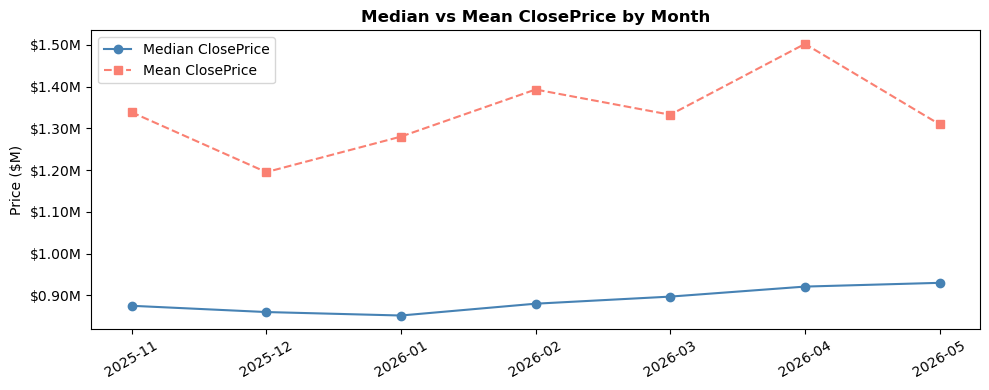

In [19]:
# Monthly median vs mean ClosePrice trend
# Mean > median confirms right skew from high-end properties
monthly_price = (
    df.groupby('CloseYearMonth')['ClosePrice']
    .agg(median='median', mean='mean', count='count')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_price['CloseYearMonth'].astype(str), monthly_price['median']/1e6,
        marker='o', color='steelblue', label='Median ClosePrice')
ax.plot(monthly_price['CloseYearMonth'].astype(str), monthly_price['mean']/1e6,
        marker='s', linestyle='--', color='salmon', label='Mean ClosePrice')
ax.set_title('Median vs Mean ClosePrice by Month', fontweight='bold')
ax.set_ylabel('Price ($M)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.2f}M'))
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 4. Size Features

LivingArea summary (Decimal 14.2 — total livable area):
count    71432.000000
mean      2053.831846
std       1038.535401
min          0.000000
25%       1387.000000
50%       1824.000000
75%       2451.000000
max      31068.000000
Name: LivingArea, dtype: float64

Records with LivingArea == 0 (data error): 20


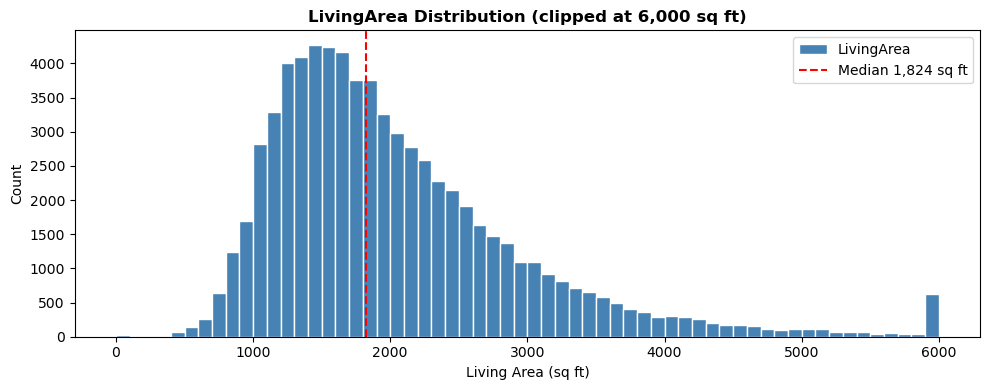

In [20]:
# LivingArea — Trestle Decimal 14.2: "The total livable area within the structure"
# NOTE: AboveGradeFinishedArea and BuildingAreaTotal are 100% null in this extract
# LivingArea is the only usable area field

print('LivingArea summary (Decimal 14.2 — total livable area):')
print(df['LivingArea'].describe())
print(f'\nRecords with LivingArea == 0 (data error): {(df["LivingArea"]==0).sum()}')

fig, ax = plt.subplots(figsize=(10, 4))
df['LivingArea'].clip(upper=6000).plot(
    kind='hist', bins=60, ax=ax, color='steelblue', edgecolor='white'
)
ax.axvline(df['LivingArea'].median(), color='red', linestyle='--',
           linewidth=1.5, label=f'Median {df["LivingArea"].median():,.0f} sq ft')
ax.set_title('LivingArea Distribution (clipped at 6,000 sq ft)', fontweight='bold')
ax.set_xlabel('Living Area (sq ft)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

LotSizeSquareFeet summary (Decimal 14.2):
count    7.023900e+04
mean     4.813743e+05
std      2.122478e+07
min      0.000000e+00
25%      5.663000e+03
50%      7.260000e+03
75%      1.045400e+04
max      1.938943e+09
Name: LotSizeSquareFeet, dtype: float64


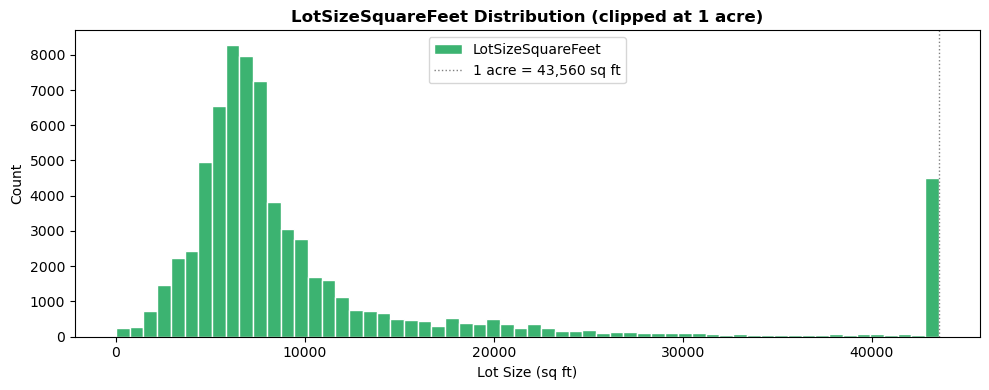

In [21]:
# LotSizeSquareFeet — Trestle Decimal 14.2
# Preferred over LotSizeAcres (redundant) and LotSizeArea (units defined separately)
# LotSizeDimensions is String 150 — freeform text, not usable for modelling

print('LotSizeSquareFeet summary (Decimal 14.2):')
print(df['LotSizeSquareFeet'].describe())

fig, ax = plt.subplots(figsize=(10, 4))
df['LotSizeSquareFeet'].dropna().clip(upper=43560).plot(   # 43560 = 1 acre
    kind='hist', bins=60, ax=ax, color='mediumseagreen', edgecolor='white'
)
ax.axvline(43560, color='gray', linestyle=':', linewidth=1, label='1 acre = 43,560 sq ft')
ax.set_title('LotSizeSquareFeet Distribution (clipped at 1 acre)', fontweight='bold')
ax.set_xlabel('Lot Size (sq ft)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Layout Features

BedroomsTotal == 0: 31 records (flag for review)


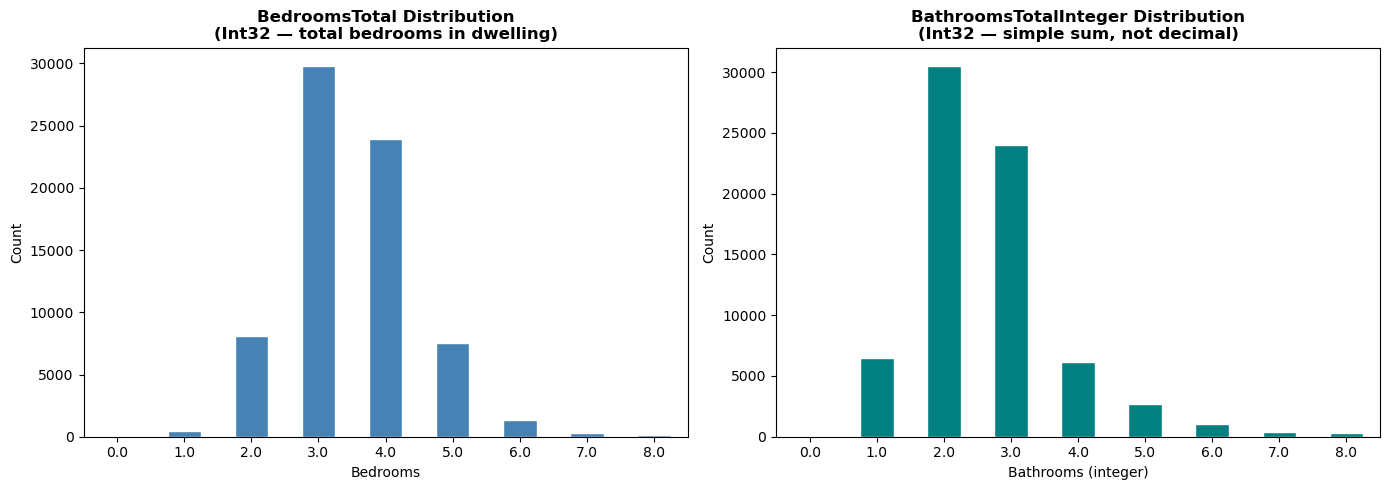

In [22]:
# BedroomsTotal — Trestle Int32: "The total number of bedrooms in the dwelling"
# BathroomsTotalInteger — Trestle Int32:
#   "The simple sum of the number of bathrooms. For a property with two Full and one Half,
#    BathroomsTotalInteger = 3. Decimal bathrooms (e.g. 2.5) require a non-standard field."

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

beds = df['BedroomsTotal'].clip(upper=8).value_counts().sort_index()
beds.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('BedroomsTotal Distribution\n(Int32 — total bedrooms in dwelling)',
                  fontweight='bold')
axes[0].set_xlabel('Bedrooms')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
print(f'BedroomsTotal == 0: {(df["BedroomsTotal"]==0).sum()} records (flag for review)')

baths = df['BathroomsTotalInteger'].clip(upper=8).value_counts().sort_index()
baths.plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('BathroomsTotalInteger Distribution\n(Int32 — simple sum, not decimal)',
                  fontweight='bold')
axes[1].set_xlabel('Bathrooms (integer)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

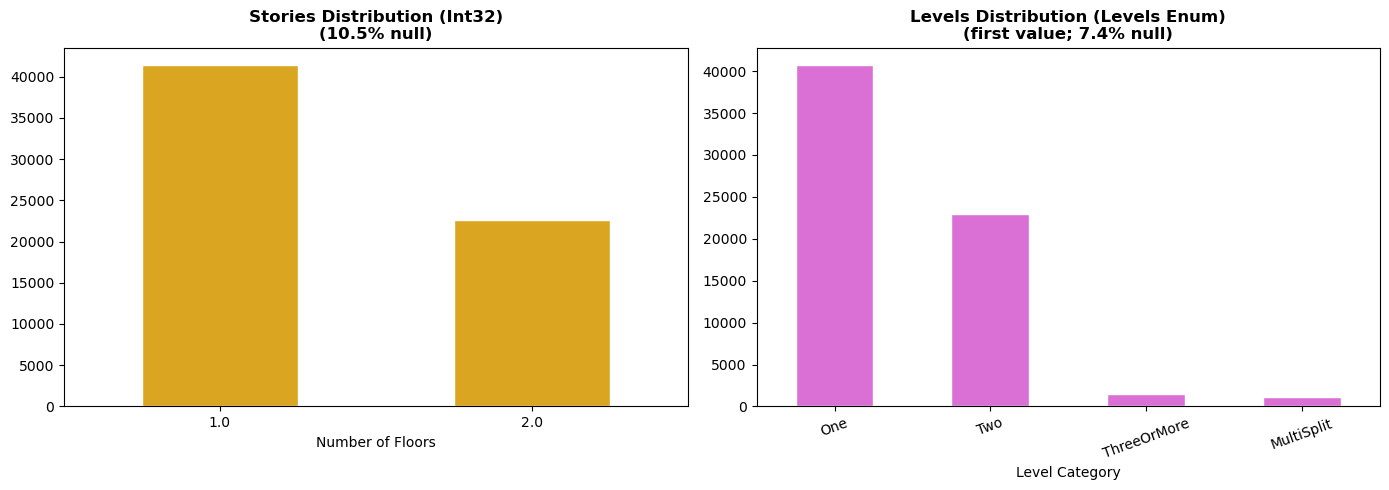

In [23]:
# Stories — Trestle Int32: "The number of floors in the property being sold"
# Levels — Trestle Levels Enum: descriptive version
#   Values: One, Two, ThreeOrMore, MultiSplit (and multi-value combinations)
# Both capture floors — Levels is better populated for low-null analysis

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Stories'].dropna().clip(upper=5).value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='goldenrod', edgecolor='white'
)
axes[0].set_title(f'Stories Distribution (Int32)\n(10.5% null)', fontweight='bold')
axes[0].set_xlabel('Number of Floors')
axes[0].tick_params(axis='x', rotation=0)

# Simplify Levels: take only the first value for multi-value records
df['Levels_primary'] = df['Levels'].str.split(',').str[0]
df['Levels_primary'].value_counts().head(6).plot(
    kind='bar', ax=axes[1], color='orchid', edgecolor='white'
)
axes[1].set_title('Levels Distribution (Levels Enum)\n(first value; 7.4% null)', fontweight='bold')
axes[1].set_xlabel('Level Category')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
## 6. Age & Market Timing

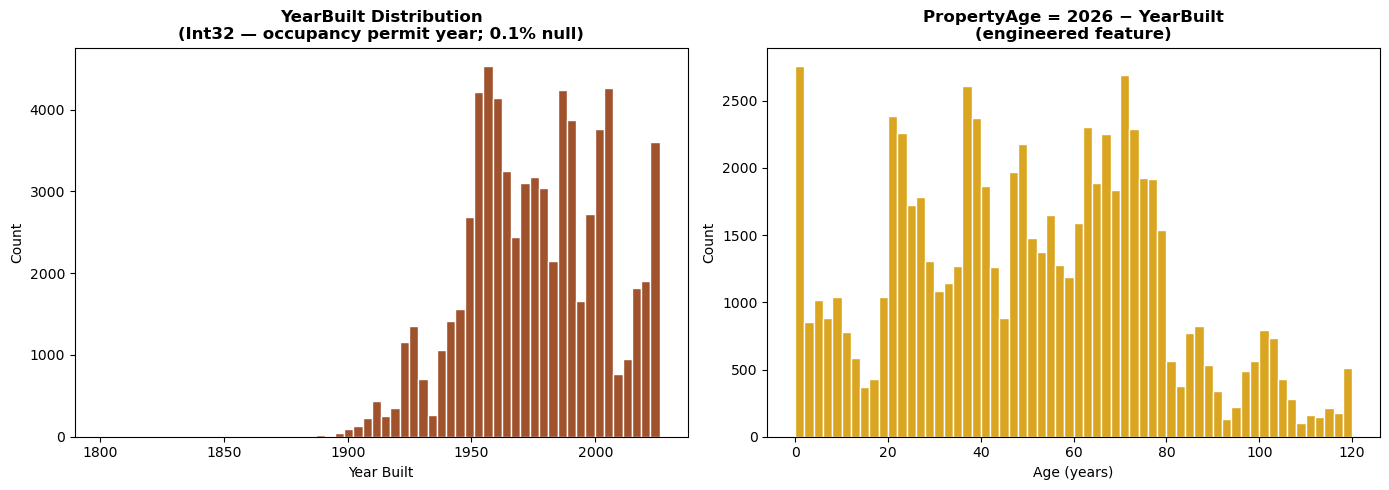

count    71425.000000
mean        49.797494
std         27.716933
min          0.000000
25%         27.000000
50%         49.000000
75%         70.000000
max        225.000000
Name: PropertyAge, dtype: float64


In [24]:
# YearBuilt — Trestle Int32:
#   "The year that an occupancy permit is first granted for the house."
# Engineer PropertyAge = 2026 - YearBuilt (feature for Week 3)

df['PropertyAge'] = 2026 - df['YearBuilt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['YearBuilt'].dropna().plot(
    kind='hist', bins=60, ax=axes[0], color='sienna', edgecolor='white'
)
axes[0].set_title('YearBuilt Distribution\n(Int32 — occupancy permit year; 0.1% null)',
                  fontweight='bold')
axes[0].set_xlabel('Year Built')
axes[0].set_ylabel('Count')

df['PropertyAge'].clip(lower=0, upper=120).plot(
    kind='hist', bins=60, ax=axes[1], color='goldenrod', edgecolor='white'
)
axes[1].set_title('PropertyAge = 2026 − YearBuilt\n(engineered feature)', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(df['PropertyAge'].describe())

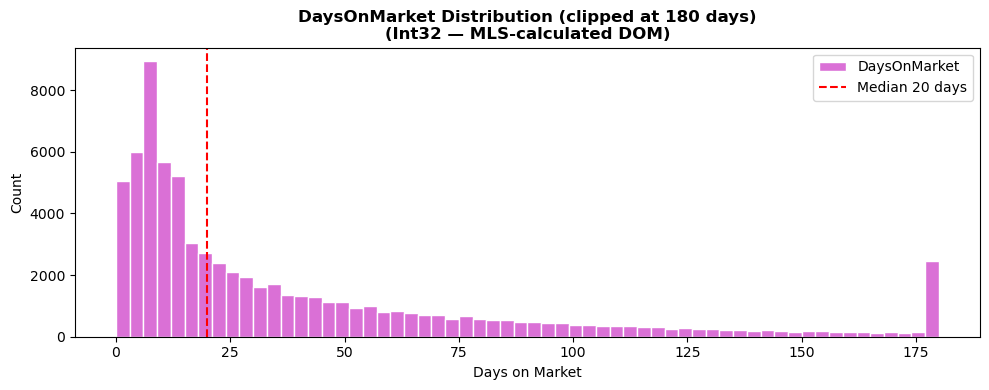

count    71466.000000
mean        41.758165
std         56.980593
min       -265.000000
25%          8.000000
50%         20.000000
75%         54.000000
max       2177.000000
Name: DaysOnMarket, dtype: float64


In [25]:
# DaysOnMarket — Trestle Int32:
#   "The number of days the listing is on market, as defined by the MLS business rules."
# Note: this is calculated by the MLS, not derived from ListingContractDate - CloseDate

fig, ax = plt.subplots(figsize=(10, 4))
df['DaysOnMarket'].clip(lower=0, upper=180).plot(
    kind='hist', bins=60, ax=ax, color='orchid', edgecolor='white'
)
ax.axvline(df['DaysOnMarket'].median(), color='red', linestyle='--',
           linewidth=1.5, label=f'Median {df["DaysOnMarket"].median():.0f} days')
ax.set_title('DaysOnMarket Distribution (clipped at 180 days)\n(Int32 — MLS-calculated DOM)',
             fontweight='bold')
ax.set_xlabel('Days on Market')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(df['DaysOnMarket'].describe())

---
## 7. Price Signals: ListPrice & OriginalListPrice

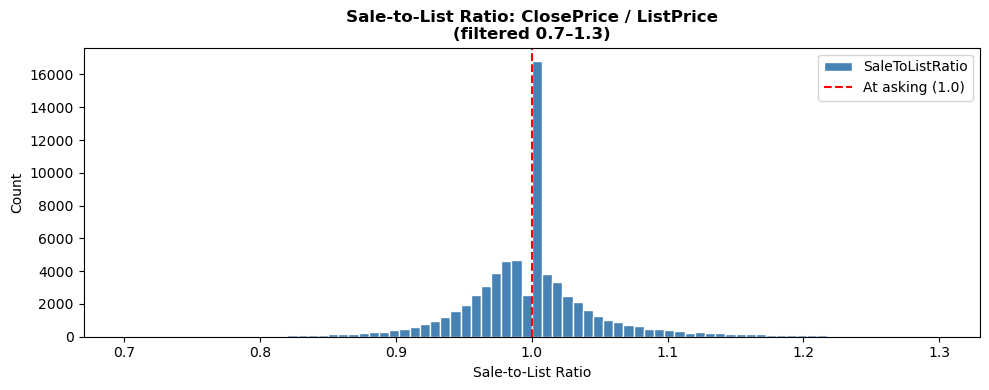

Median Sale-to-List Ratio : 1.000
% sold above asking       : 39.0%
% sold below asking       : 44.3%
% with price reduction    : 27.9%


In [26]:
# ListPrice — Trestle Decimal 14.2:
#   "The current price of the property as determined by the seller and seller's broker."
# OriginalListPrice — Trestle Decimal 14.2:
#   "The original price on the initial agreement between the seller and the seller's broker."
# When ListPrice < OriginalListPrice, a price reduction occurred before sale.

# Sale-to-List Ratio = ClosePrice / ListPrice
df['SaleToListRatio'] = df['ClosePrice'] / df['ListPrice']

# Price Reduction flag (engineered feature)
df['PriceReductionYN'] = df['ListPrice'] < df['OriginalListPrice']

stl_filtered = df[(df['SaleToListRatio'] >= 0.7) & (df['SaleToListRatio'] <= 1.3)]

fig, ax = plt.subplots(figsize=(10, 4))
stl_filtered['SaleToListRatio'].plot(
    kind='hist', bins=80, ax=ax, color='steelblue', edgecolor='white'
)
ax.axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='At asking (1.0)')
ax.set_title('Sale-to-List Ratio: ClosePrice / ListPrice\n(filtered 0.7–1.3)', fontweight='bold')
ax.set_xlabel('Sale-to-List Ratio')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median Sale-to-List Ratio : {df["SaleToListRatio"].median():.3f}')
print(f'% sold above asking       : {(df["SaleToListRatio"] > 1.0).mean()*100:.1f}%')
print(f'% sold below asking       : {(df["SaleToListRatio"] < 1.0).mean()*100:.1f}%')
print(f'% with price reduction    : {df["PriceReductionYN"].mean()*100:.1f}%')

---
## 8. Boolean Amenity Features

/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_78628/709442578.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  true_pct = df[col].fillna(False).mean() * 100


,definition,null_pct,true_pct
field,,,
ViewYN,The property has a view,8.690846,56.846612
WaterfrontYN,The property is on the waterfront (99.9% null ...,99.948227,0.051773
BasementYN,Does the property have a basement? (97.6% null...,97.603056,2.396944
PoolPrivateYN,Privately owned pool included in sale,7.814905,15.492682
AttachedGarageYN,Garage attached to main/primary dwelling,12.155431,73.418129
FireplaceYN,Property includes a fireplace,0.088154,72.399463
NewConstructionYN,"Newly constructed, not previously occupied",7.550444,3.573727


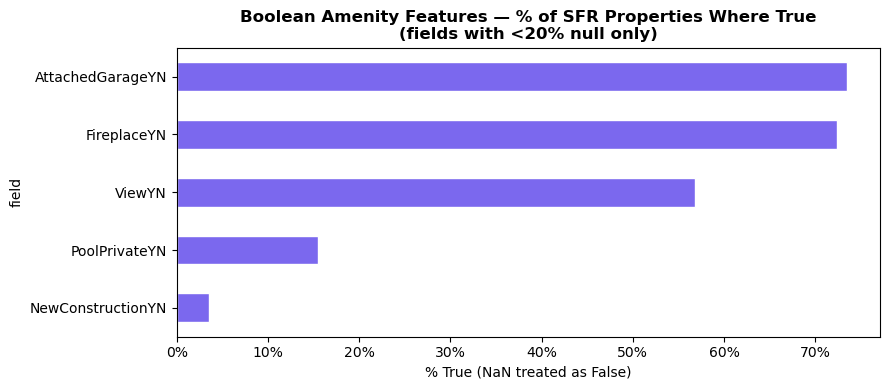

In [27]:
# All Boolean fields from Trestle schema — with null rates and true rates
# WaterfrontYN and BasementYN are nearly 100% null — will be dropped

bool_fields = {
    'ViewYN':          'The property has a view',
    'WaterfrontYN':    'The property is on the waterfront (99.9% null — DROP)',
    'BasementYN':      'Does the property have a basement? (97.6% null — DROP)',
    'PoolPrivateYN':   'Privately owned pool included in sale',
    'AttachedGarageYN':'Garage attached to main/primary dwelling',
    'FireplaceYN':     'Property includes a fireplace',
    'NewConstructionYN':'Newly constructed, not previously occupied',
}

bool_summary = []
for col, desc in bool_fields.items():
    if col in df.columns:
        null_pct = df[col].isna().mean() * 100
        true_pct = df[col].fillna(False).mean() * 100
        bool_summary.append({'field': col, 'definition': desc,
                              'null_pct': null_pct, 'true_pct': true_pct})

bool_df = pd.DataFrame(bool_summary).set_index('field')
display(bool_df)

# Plot true rates for usable fields only (null < 20%)
usable_bool = bool_df[bool_df['null_pct'] < 20]
fig, ax = plt.subplots(figsize=(9, 4))
usable_bool['true_pct'].sort_values().plot(
    kind='barh', ax=ax, color='mediumslateblue', edgecolor='white'
)
ax.set_title('Boolean Amenity Features — % of SFR Properties Where True\n(fields with <20% null only)',
             fontweight='bold')
ax.set_xlabel('% True (NaN treated as False)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

In [28]:
# ClosePrice premium for boolean features
print('Median ClosePrice by boolean amenity presence:')
for col in ['PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'AttachedGarageYN', 'NewConstructionYN']:
    if col in df.columns:
        grp = df.copy()
        grp[col] = grp[col].fillna(False)
        prices = grp.groupby(col)['ClosePrice'].median()
        if True in prices.index and False in prices.index:
            premium = prices[True] - prices[False]
            print(f'  {col}: False=${prices[False]/1e6:.3f}M, True=${prices[True]/1e6:.3f}M '
                  f'(premium: ${premium:,.0f})')

Median ClosePrice by boolean amenity presence:


/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_78628/1701322814.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grp[col] = grp[col].fillna(False)


  PoolPrivateYN: False=$0.858M, True=$1.149M (premium: $291,000)
  ViewYN: False=$0.875M, True=$0.900M (premium: $25,000)
  FireplaceYN: False=$0.715M, True=$1.000M (premium: $285,000)
  AttachedGarageYN: False=$0.885M, True=$0.890M (premium: $5,000)
  NewConstructionYN: False=$0.900M, True=$0.665M (premium: $-234,785)


---
## 9. Categorical & Enum Features

In [29]:
# AssociationFee — Trestle Decimal 14.2: "A fee paid by homeowner to HOA"
# AssociationFeeFrequency — Trestle FeeFrequency Enum: Monthly/Annually/Quarterly/SemiAnnually
# 74% null on Frequency (and 28.6% null on Fee) → NaN likely means no HOA
# Strategy: normalize all fees to monthly equivalent

print('AssociationFeeFrequency value counts (FeeFrequency Enum):')
print(df['AssociationFeeFrequency'].value_counts())
print(f'\nNull: {df["AssociationFeeFrequency"].isna().sum():,} ({df["AssociationFeeFrequency"].isna().mean()*100:.1f}%) — treat as no HOA')

print('\nAssociationFee where > 0:')
print(df[df['AssociationFee'] > 0]['AssociationFee'].describe())

AssociationFeeFrequency value counts (FeeFrequency Enum):
AssociationFeeFrequency
Monthly         16371
Annually         1425
Quarterly         696
SemiAnnually      111
Name: count, dtype: int64

Null: 52,863 (74.0%) — treat as no HOA

AssociationFee where > 0:
count    18713.000000
mean       303.107258
std        566.944993
min          0.030000
25%        120.000000
50%        196.500000
75%        340.000000
max      20712.000000
Name: AssociationFee, dtype: float64


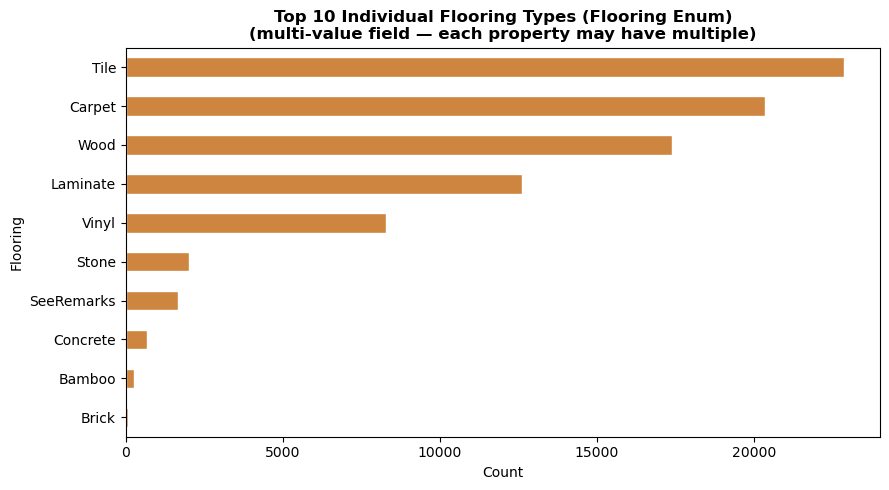

In [30]:
# Flooring — Trestle Flooring Enum: "A list of the type(s) of flooring found within the property"
# 235 unique combinations (comma-separated multi-value strings)
# Strategy: create binary flags for the most common individual floor types

# Extract individual flooring types from multi-value strings
flooring_exploded = df['Flooring'].dropna().str.split(',').explode().str.strip()
top_flooring = flooring_exploded.value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
top_flooring.sort_values().plot(kind='barh', ax=ax, color='peru', edgecolor='white')
ax.set_title('Top 10 Individual Flooring Types (Flooring Enum)\n(multi-value field — each property may have multiple)',
             fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

---
## 10. Geographic Distribution

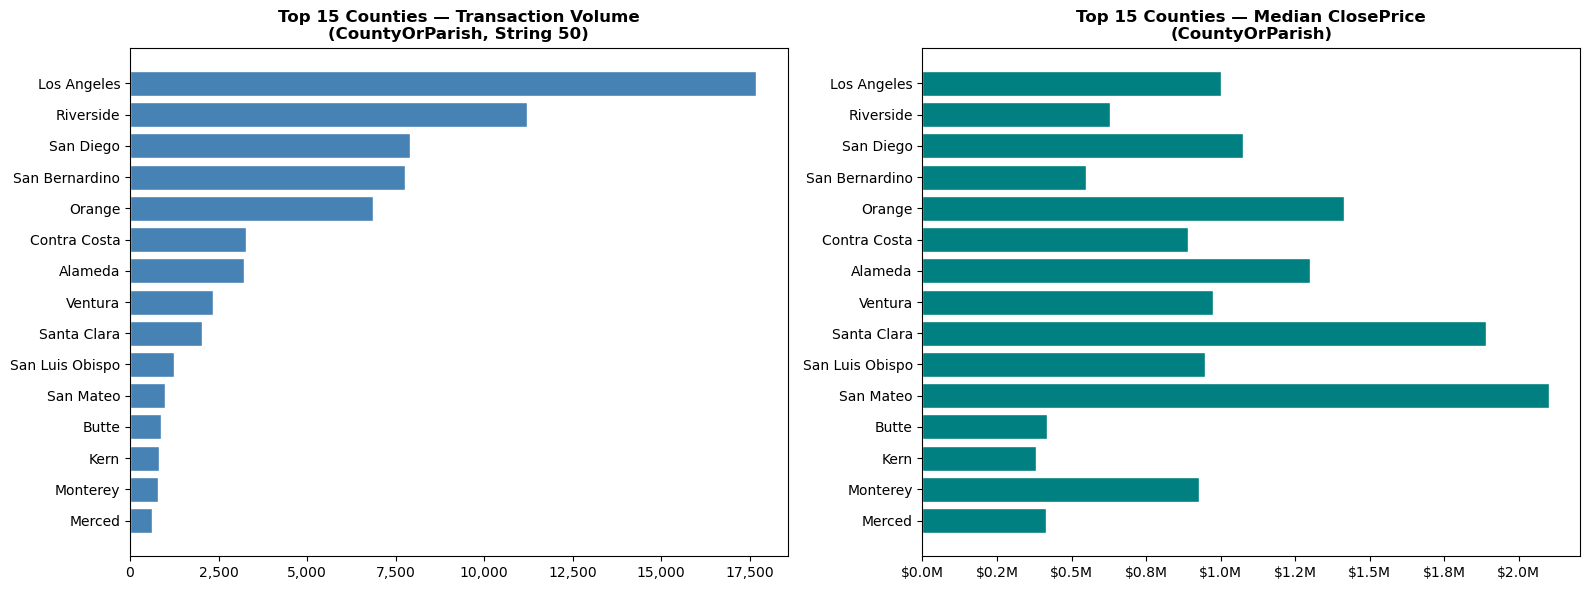

In [31]:
# CountyOrParish — Trestle String 50: "The County, Parish or other regional authority"
# 60 unique counties — good cardinality for a categorical feature

county_stats = (
    df.groupby('CountyOrParish')['ClosePrice']
    .agg(count='count', median_price='median')
    .sort_values('count', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(county_stats['CountyOrParish'], county_stats['count'],
             color='steelblue', edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Counties — Transaction Volume\n(CountyOrParish, String 50)',
                  fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].barh(county_stats['CountyOrParish'], county_stats['median_price']/1e6,
             color='teal', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Counties — Median ClosePrice\n(CountyOrParish)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}M'))

plt.tight_layout()
plt.show()

In [32]:
# PostalCode — Trestle String 10: "The postal code portion of a street or mailing address"
# 1,675 unique ZIP codes — high cardinality; consider target encoding in Week 3

zip_stats = (
    df.groupby('PostalCode')['ClosePrice']
    .agg(count='count', median_price='median')
)
print(f'Unique PostalCodes (String 10): {df["PostalCode"].nunique():,}')
print(f'ZIP codes with fewer than 10 transactions: {(zip_stats["count"] < 10).sum()}')
print('\nTop 10 ZIP codes by volume:')
print(zip_stats.sort_values('count', ascending=False).head(10))

Unique PostalCodes (String 10): 1,675
ZIP codes with fewer than 10 transactions: 788

Top 10 ZIP codes by volume:
            count  median_price
PostalCode                     
92253         541      975000.0
92345         435      467090.0
92584         407      620000.0
92211         382      575000.0
92223         373      530000.0
92592         373      805000.0
92596         363      627590.0
92336         336      720500.0
92562         335      710000.0
93536         315      540000.0


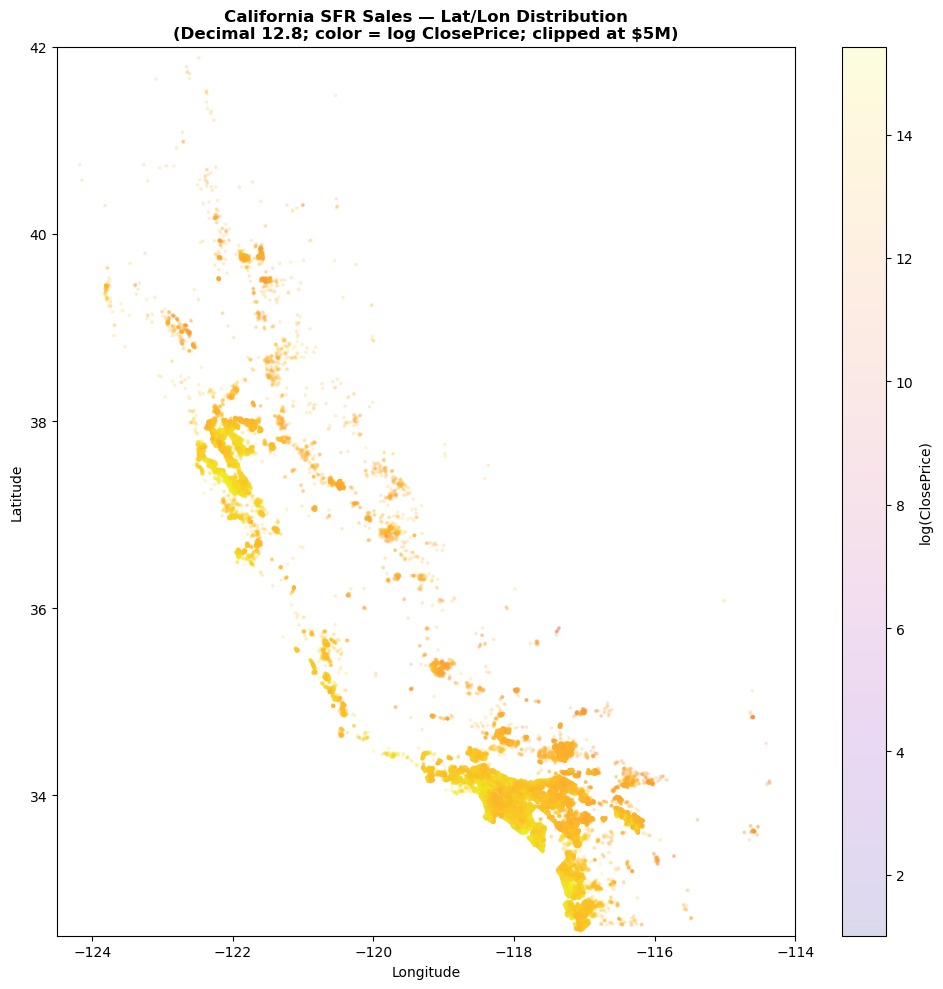

In [33]:
# Latitude / Longitude — Trestle Decimal 12.8:
#   "Geographic latitude/longitude of some reference point on the property"
# Use for: geographic scatter, distance features, school district spatial join (Week 6)

geo = df[df['ClosePrice'] < 5_000_000].dropna(subset=['Latitude', 'Longitude'])

fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(
    geo['Longitude'], geo['Latitude'],
    c=np.log1p(geo['ClosePrice']), cmap='plasma',
    alpha=0.15, s=3
)
plt.colorbar(sc, ax=ax, label='log(ClosePrice)')
ax.set_title('California SFR Sales — Lat/Lon Distribution\n'
             '(Decimal 12.8; color = log ClosePrice; clipped at $5M)',
             fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Restrict to California bounding box
ax.set_xlim(-124.5, -114.0)
ax.set_ylim(32.5, 42.0)

plt.tight_layout()
plt.show()

In [34]:
# HighSchoolDistrict — Trestle String 50:
#   "The name of the high school district having a catchment area that includes the property.
#    When only one school district is used, this field should be used over Junior or Elementary."
# 26.9% null — will be supplemented by spatial join in Week 6

print(f'HighSchoolDistrict: {df["HighSchoolDistrict"].nunique()} unique values, '
      f'{df["HighSchoolDistrict"].isna().mean()*100:.1f}% null')
print()
print('Top 15 HighSchoolDistricts by volume:')
hsd = df.groupby('HighSchoolDistrict')['ClosePrice'].agg(count='count', median='median')
print(hsd.sort_values('count', ascending=False).head(15))

# Note: ElementarySchoolDistrict and MiddleOrJuniorSchoolDistrict are 100% null
# ElementarySchool (87.3% null), MiddleOrJuniorSchool (87.2% null), HighSchool (83.2% null)
# → Only HighSchoolDistrict is usable from the school fields in this extract

HighSchoolDistrict: 400 unique values, 26.9% null

Top 15 HighSchoolDistricts by volume:
                             count     median
HighSchoolDistrict                           
Los Angeles Unified           4305   920000.0
Other                         4257  1424000.0
Capistrano Unified            1326  1700000.0
Riverside Unified              912   680000.0
Corona-Norco Unified           838   840000.0
Long Beach Unified             818   965000.0
William S. Hart Union          796   875000.0
Hemet Unified                  778   474000.0
Temecula Unified               740   755000.0
San Bernardino City Unified    726   525000.0
Perris Union High              694   585000.0
Saddleback Valley Unified      662  1355000.0
Antelope Valley Union          655   489000.0
Lake Elsinore Unified          616   649000.0
San Diego Unified              606  1047500.0


---
## 11. Correlation with ClosePrice

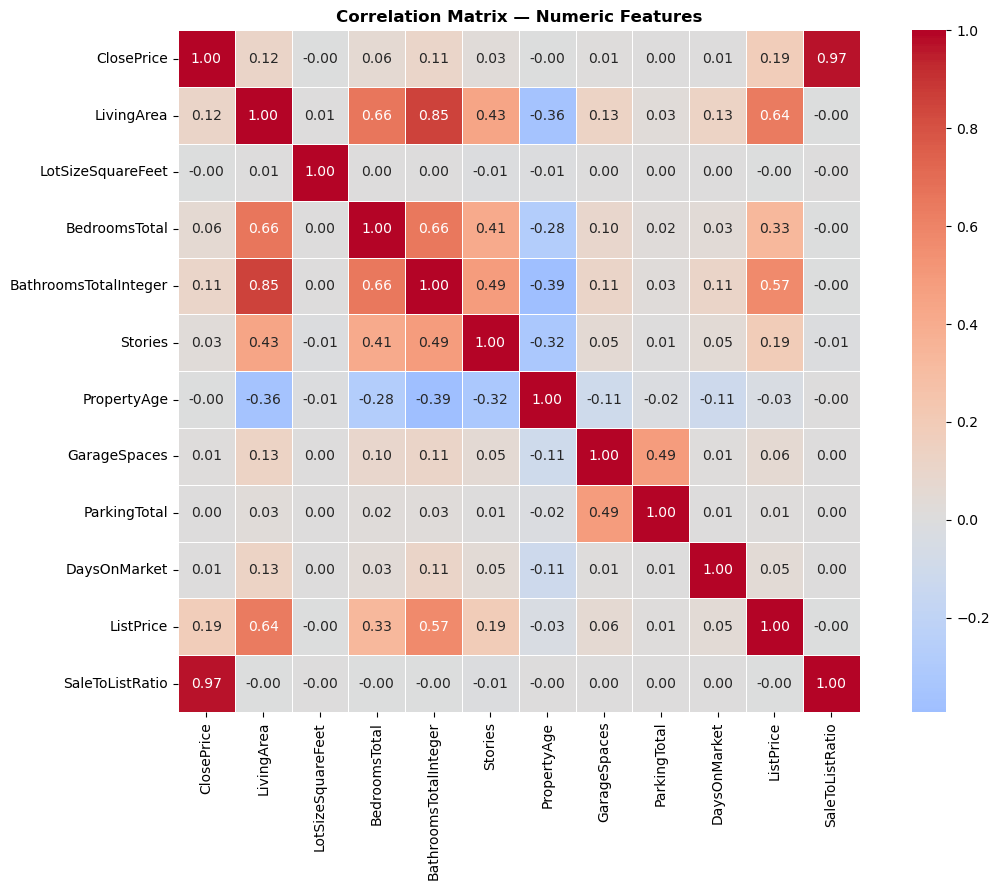

In [35]:
# Numeric features confirmed present and usable from Trestle schema
NUMERIC_FEATURES = [
    'ClosePrice',
    'LivingArea',           # Decimal 14.2 — total livable area
    'LotSizeSquareFeet',    # Decimal 14.2 — total lot area
    'BedroomsTotal',        # Int32 — total bedrooms
    'BathroomsTotalInteger',# Int32 — simple sum of bathrooms
    'Stories',              # Int32 — number of floors
    'PropertyAge',          # engineered from YearBuilt (Int32)
    'GarageSpaces',         # Decimal 14.2 — number of garage spaces
    'ParkingTotal',         # Decimal 14.2 — total spaces
    'DaysOnMarket',         # Int32 — MLS-calculated DOM
    'ListPrice',            # Decimal 14.2 — current asking price
    'SaleToListRatio',      # engineered: ClosePrice / ListPrice
]

corr = df[NUMERIC_FEATURES].corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

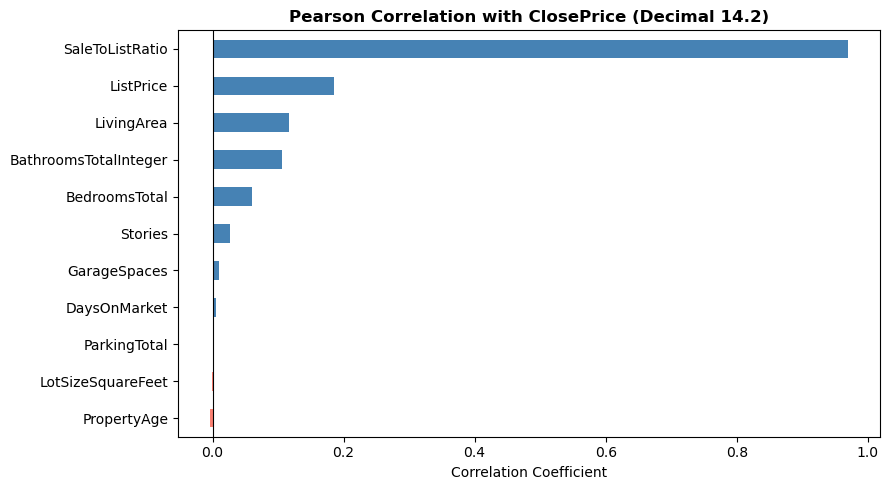

In [36]:
# Sorted bar: correlation with ClosePrice
cp_corr = corr['ClosePrice'].drop('ClosePrice').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
cp_corr.plot(
    kind='barh', ax=ax,
    color=cp_corr.map(lambda x: 'steelblue' if x > 0 else 'salmon')
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with ClosePrice (Decimal 14.2)', fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

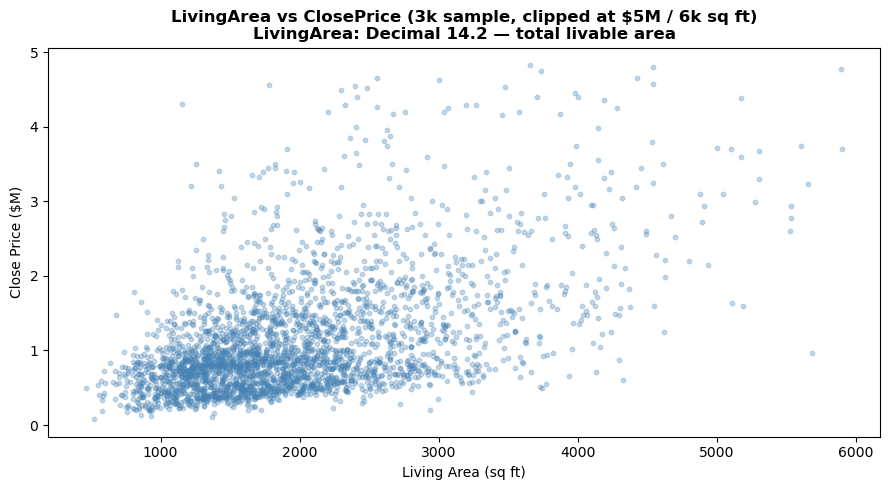

In [37]:
# LivingArea vs ClosePrice — the core size/price relationship
sample = df[
    (df['ClosePrice'] < 5_000_000) &
    (df['LivingArea'] > 0) &
    (df['LivingArea'] < 6000)
].sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(sample['LivingArea'], sample['ClosePrice']/1e6,
           alpha=0.3, s=10, color='steelblue')
ax.set_title('LivingArea vs ClosePrice (3k sample, clipped at $5M / 6k sq ft)\n'
             'LivingArea: Decimal 14.2 — total livable area',
             fontweight='bold')
ax.set_xlabel('Living Area (sq ft)')
ax.set_ylabel('Close Price ($M)')
plt.tight_layout()
plt.show()

---
## 12. Price Per Square Foot Analysis

`PricePerSqFt = ClosePrice / LivingArea` is one of the most widely used derived metrics in real
estate. It normalises price by size, making properties comparable across different square footages.
Mapping median price/sqft by county and ZIP reveals where value density is highest — directly
informing how geographic features are weighted in the model.

PricePerSqFt summary:
count     71412.000000
mean        650.410906
std        4622.022568
min           0.000498
5%          221.568627
25%         342.081602
50%         526.710155
75%         738.476535
95%        1258.555010
max      584239.130435
Name: PricePerSqFt, dtype: float64


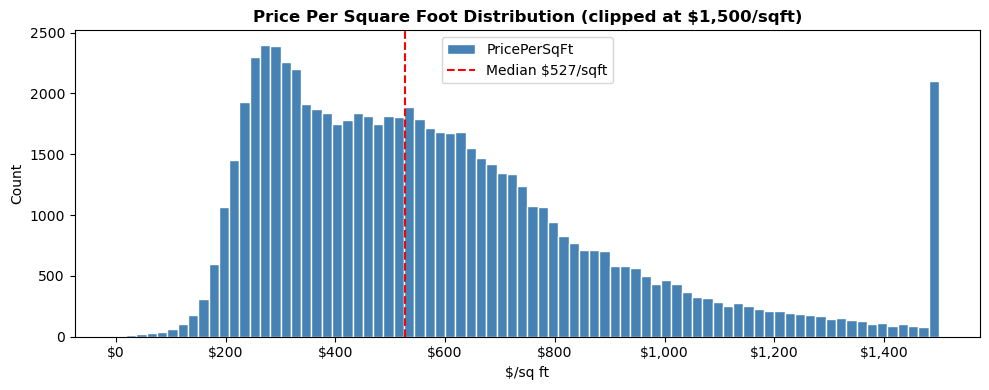

In [38]:
# Engineer PricePerSqFt — exploratory only, NOT a model input
# (would constitute target leakage if LivingArea is also a feature)
df['PricePerSqFt'] = df['ClosePrice'] / df['LivingArea'].replace(0, np.nan)

print('PricePerSqFt summary:')
print(df['PricePerSqFt'].describe(percentiles=[.05, .25, .5, .75, .95]))

fig, ax = plt.subplots(figsize=(10, 4))
df['PricePerSqFt'].clip(upper=1500).plot(
    kind='hist', bins=80, ax=ax, color='steelblue', edgecolor='white'
)
ax.axvline(df['PricePerSqFt'].median(), color='red', linestyle='--',
           linewidth=1.5, label=f'Median ${df["PricePerSqFt"].median():,.0f}/sqft')
ax.set_title('Price Per Square Foot Distribution (clipped at $1,500/sqft)', fontweight='bold')
ax.set_xlabel('$/sq ft')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

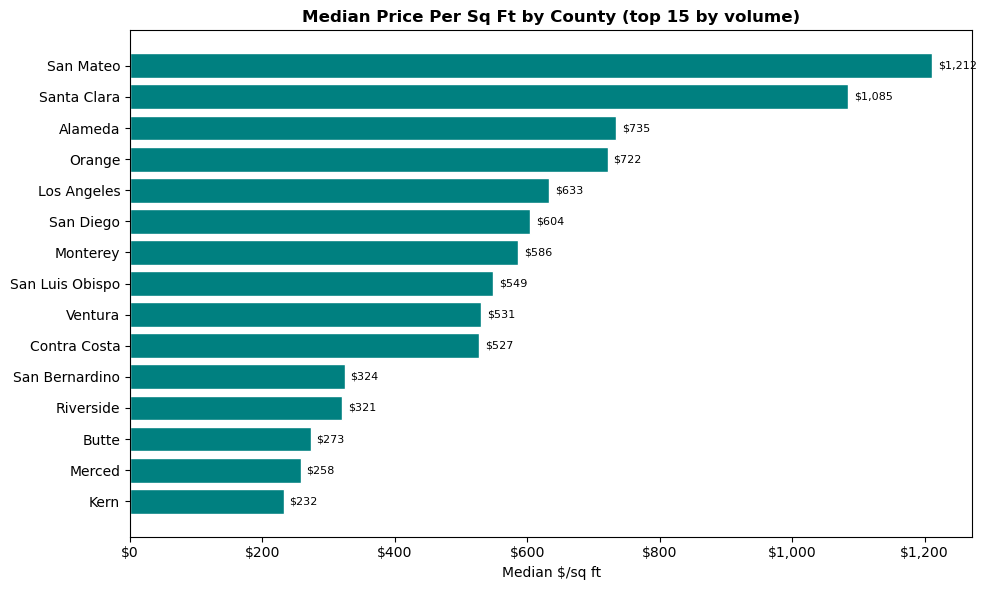

In [39]:
# Median PricePerSqFt by county — top 15 by volume
ppsf_county = (
    df.groupby('CountyOrParish')['PricePerSqFt']
    .agg(median_ppsf='median', count='count')
    .sort_values('count', ascending=False)
    .head(15)
    .sort_values('median_ppsf')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(ppsf_county.index, ppsf_county['median_ppsf'],
               color='teal', edgecolor='white')
ax.bar_label(bars, labels=[f'${v:,.0f}' for v in ppsf_county['median_ppsf']],
             padding=4, fontsize=8)
ax.set_title('Median Price Per Sq Ft by County (top 15 by volume)', fontweight='bold')
ax.set_xlabel('Median $/sq ft')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

In [40]:
# Median PricePerSqFt by ZIP — top 20 most expensive ZIPs
# Useful for identifying high-value micro-markets
ppsf_zip = (
    df[df['PostalCode'].notna()]
    .groupby('PostalCode')['PricePerSqFt']
    .agg(median_ppsf='median', count='count')
)
# Only include ZIPs with at least 10 transactions for reliability
ppsf_zip_reliable = ppsf_zip[ppsf_zip['count'] >= 10].sort_values('median_ppsf', ascending=False)

print('Top 20 ZIPs by Median PricePerSqFt (min 10 transactions):')
print(ppsf_zip_reliable.head(20).to_string())
print(f'\nBottom 20 ZIPs by Median PricePerSqFt (min 10 transactions):')
print(ppsf_zip_reliable.tail(20).to_string())

Top 20 ZIPs by Median PricePerSqFt (min 10 transactions):
            median_ppsf  count
PostalCode                    
92661       2622.372494     28
92662       2485.253920     14
94301       2194.600893     33
92625       2076.606521     63
94306       2046.943231     39
93921       2036.124445     26
90402       1994.401679     45
94303       1928.500693     54
94027       1915.139458     16
94040       1911.637720     30
93108       1892.414393     24
94024       1887.662273     34
94022       1786.346539     32
92663       1734.799980     52
94087       1727.620087     69
94025       1709.726444     81
92657       1709.528765     49
90403       1679.322430     19
95014       1659.187396     54
90743       1646.084642     10

Bottom 20 ZIPs by Median PricePerSqFt (min 10 transactions):
            median_ppsf  count
PostalCode                    
95467        208.083222     50
92274        207.602339     39
93501        206.299749     12
95422        203.761755     51
92440       

---
## 13. Seasonality & Temporal Patterns

7 months spanning two calendar years allows us to examine whether `CloseMonth` is a meaningful
signal. Spring (March–May) is historically the hottest selling season in California — worth
confirming whether that pattern shows up in price, DOM, and sale-to-list ratio.

In [41]:
# Month name map for readable labels
MONTH_NAMES = {11: 'Nov', 12: 'Dec', 1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May'}
df['CloseMonthName'] = df['CloseMonth'].map(MONTH_NAMES)

# Month order for plots (chronological Nov→May)
MONTH_ORDER = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May']

monthly_stats = (
    df.groupby('CloseMonthName')
    .agg(
        count=('ClosePrice', 'count'),
        median_price=('ClosePrice', 'median'),
        median_ppsf=('PricePerSqFt', 'median'),
        median_dom=('DaysOnMarket', 'median'),
        median_stl=('SaleToListRatio', 'median')
    )
    .reindex(MONTH_ORDER)
    .reset_index()
)

print('Monthly seasonality summary:')
display(monthly_stats)

Monthly seasonality summary:


,CloseMonthName,count,median_price,median_ppsf,median_dom,median_stl
0,Nov,9739,875000.0,519.858505,24.0,1.0000
1,Dec,10455,860000.0,510.582011,26.0,1.0000
2,Jan,7490,851691.5,498.734705,30.0,0.9968
3,Feb,8550,880000.0,528.317836,21.0,1.0000
4,Mar,11177,897000.0,529.733424,16.0,1.0000
5,Apr,12031,921000.0,545.330607,14.0,1.0000
6,May,12024,930000.0,542.237443,15.0,1.0000


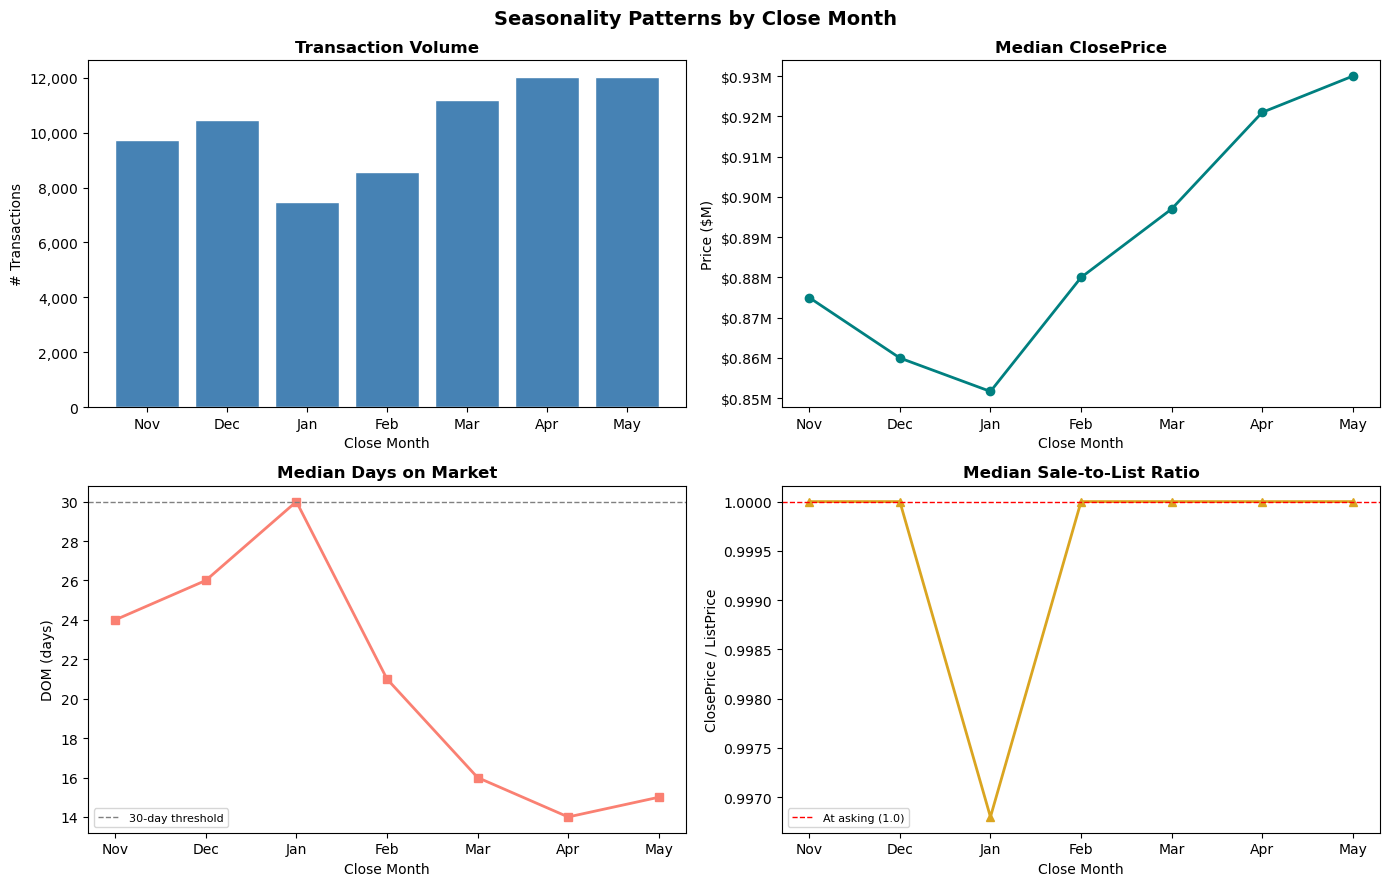

In [42]:
# 4-panel seasonality dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Seasonality Patterns by Close Month', fontsize=14, fontweight='bold')

# Panel 1: Transaction volume
axes[0, 0].bar(monthly_stats['CloseMonthName'], monthly_stats['count'],
               color='steelblue', edgecolor='white')
axes[0, 0].set_title('Transaction Volume', fontweight='bold')
axes[0, 0].set_ylabel('# Transactions')
axes[0, 0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Panel 2: Median ClosePrice
axes[0, 1].plot(monthly_stats['CloseMonthName'], monthly_stats['median_price']/1e6,
                marker='o', color='teal', linewidth=2)
axes[0, 1].set_title('Median ClosePrice', fontweight='bold')
axes[0, 1].set_ylabel('Price ($M)')
axes[0, 1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.2f}M'))

# Panel 3: Median Days on Market
axes[1, 0].plot(monthly_stats['CloseMonthName'], monthly_stats['median_dom'],
                marker='s', color='salmon', linewidth=2)
axes[1, 0].set_title('Median Days on Market', fontweight='bold')
axes[1, 0].set_ylabel('DOM (days)')
axes[1, 0].axhline(30, color='gray', linestyle='--', linewidth=1, label='30-day threshold')
axes[1, 0].legend(fontsize=8)

# Panel 4: Median Sale-to-List Ratio
axes[1, 1].plot(monthly_stats['CloseMonthName'], monthly_stats['median_stl'],
                marker='^', color='goldenrod', linewidth=2)
axes[1, 1].set_title('Median Sale-to-List Ratio', fontweight='bold')
axes[1, 1].set_ylabel('ClosePrice / ListPrice')
axes[1, 1].axhline(1.0, color='red', linestyle='--', linewidth=1, label='At asking (1.0)')
axes[1, 1].legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlabel('Close Month')

plt.tight_layout()
plt.show()

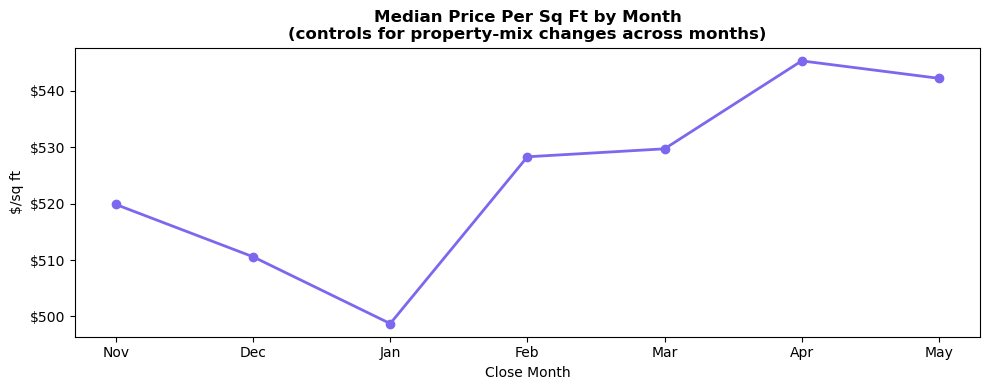

In [43]:
# Median PricePerSqFt by month — cleaner than ClosePrice for seasonality
# because it removes the confounding effect of property mix changing month to month
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_stats['CloseMonthName'], monthly_stats['median_ppsf'],
        marker='o', color='mediumslateblue', linewidth=2)
ax.set_title('Median Price Per Sq Ft by Month\n'
             '(controls for property-mix changes across months)', fontweight='bold')
ax.set_ylabel('$/sq ft')
ax.set_xlabel('Close Month')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 14. Outlier Deep Dive

Before dropping or capping outliers in Week 3, inspect the flagged records to determine
whether they are data entry errors, legitimate edge cases, or a specific geographic cluster.

In [44]:
# ── ClosePrice < $10k — likely data errors ───────────────────────
low_price = df[df['ClosePrice'] < 10_000].copy()
print(f'Records with ClosePrice < $10k: {len(low_price)}')
display(low_price[['ListingKey', 'ClosePrice', 'ListPrice', 'LivingArea',
                    'BedroomsTotal', 'City', 'CountyOrParish', 'CloseDate']].head(20))

Records with ClosePrice < $10k: 4


,ListingKey,ClosePrice,ListPrice,LivingArea,BedroomsTotal,City,CountyOrParish,CloseDate
50217,1144223437,1.75,1749000.0,3513.0,3.0,Palm Desert,Riverside,2026-01-30
55713,1110035161,8300.00,2000000.0,3886.0,5.0,Altadena,Los Angeles,2026-01-17
66917,1147508351,8000.00,8000.0,984.0,3.0,Trona,San Bernardino,2026-02-04
114423,1151459976,685.00,913655.0,2980.0,5.0,Oakley,Contra Costa,2026-04-29


Records with ClosePrice > $10M: 288
County breakdown of $10M+ records:
CountyOrParish
Los Angeles      118
Orange            78
San Diego         32
San Mateo         14
Santa Barbara     14
Riverside         11
Santa Clara        8
Ventura            4
Monterey           3
Contra Costa       3
Name: count, dtype: int64

Price distribution of $10M+ records:
count            $288
mean      $35,032,258
std      $110,381,713
min       $10,019,375
25%       $11,368,750
50%       $13,800,000
75%       $18,032,500
max      $796,000,000
Name: ClosePrice, dtype: object


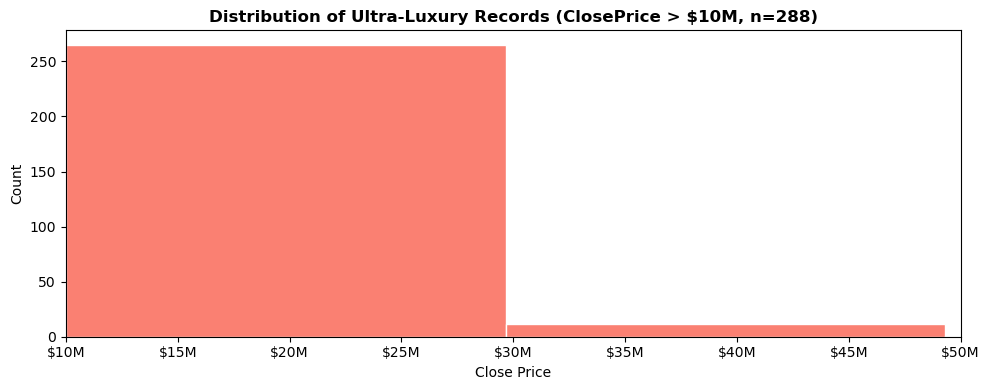

In [69]:
# ── ClosePrice > $10M — ultra-luxury, review before capping ──────
high_price = df[df['ClosePrice'] > 10_000_000].copy()
print(f'Records with ClosePrice > $10M: {len(high_price)}')
print(f'County breakdown of $10M+ records:')
print(high_price['CountyOrParish'].value_counts().head(10))
print()
print('Price distribution of $10M+ records:')
print(high_price['ClosePrice'].describe().apply(lambda x: f'${x:,.0f}'))

fig, ax = plt.subplots(figsize=(10, 4))
high_price['ClosePrice'].plot(kind='hist', bins=40, ax=ax, color='salmon', edgecolor='white')
# Limit x-axis to $100M
ax.set_xlim(10_000_000, 50_000_000)
ax.set_title(f'Distribution of Ultra-Luxury Records (ClosePrice > $10M, n={len(high_price)})',
             fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.set_xlabel('Close Price')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [46]:
# ── LivingArea == 0 — structural data errors ──────────────────────
zero_area = df[df['LivingArea'] == 0].copy()
print(f'Records with LivingArea == 0: {len(zero_area)}')
print('County breakdown:')
print(zero_area['CountyOrParish'].value_counts())
display(zero_area[['ListingKey', 'ClosePrice', 'LivingArea', 'LotSizeSquareFeet',
                    'BedroomsTotal', 'City', 'CountyOrParish']].head(10))

Records with LivingArea == 0: 20
County breakdown:
CountyOrParish
Los Angeles      11
San Diego         2
Alameda           2
Contra Costa      1
Santa Barbara     1
San Francisco     1
Riverside         1
Ventura           1
Name: count, dtype: int64


,ListingKey,ClosePrice,LivingArea,LotSizeSquareFeet,BedroomsTotal,City,CountyOrParish
19025,1068149606,9300000.0,0.0,22189.0,6.0,Beverly Hills,Los Angeles
19225,1149744659,3500000.0,0.0,6507.0,4.0,Los Angeles,Los Angeles
32451,1136715994,7300000.0,0.0,8206.7,6.0,Los Angeles,Los Angeles
33112,1134702110,1920000.0,0.0,11731.0,3.0,Los Angeles,Los Angeles
40426,1150723609,650000.0,0.0,4797.0,0.0,San Diego,San Diego
41378,1150066771,620000.0,0.0,7389.0,3.0,Oakland,Alameda
43896,1147619191,2770000.0,0.0,8640.0,3.0,Studio City,Los Angeles
44412,1147468485,540000.0,0.0,5457.0,3.0,San Pablo,Contra Costa
47707,1146102942,5280000.0,0.0,20364.0,5.0,Pacific Palisades,Los Angeles
51967,1137140936,4088000.0,0.0,4841.0,4.0,West Hollywood,Los Angeles


In [47]:
# ── BedroomsTotal == 0 — review individually ─────────────────────
zero_beds = df[df['BedroomsTotal'] == 0].copy()
print(f'Records with BedroomsTotal == 0: {len(zero_beds)}')
print('ClosePrice range for 0-bedroom records:')
print(zero_beds['ClosePrice'].describe().apply(lambda x: f'${x:,.0f}'))
display(zero_beds[['ListingKey', 'ClosePrice', 'LivingArea', 'BedroomsTotal',
                    'BathroomsTotalInteger', 'City', 'CountyOrParish']].head(10))

Records with BedroomsTotal == 0: 31
ClosePrice range for 0-bedroom records:
count           $31
mean       $846,519
std        $785,223
min         $18,000
25%        $230,000
50%        $675,000
75%      $1,117,750
max      $3,250,000
Name: ClosePrice, dtype: object


,ListingKey,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,City,CountyOrParish
7278,1137206585,3250000.0,630.0,0.0,1.0,Newport Beach,Orange
15560,1119642952,605000.0,100.0,0.0,0.0,Altadena,Los Angeles
26808,1144650137,179000.0,352.0,0.0,0.0,Yucca Valley,San Bernardino
40426,1150723609,650000.0,0.0,0.0,0.0,San Diego,San Diego
49813,1144652587,249000.0,400.0,0.0,1.0,Yucca Valley,San Bernardino
52766,1134559334,960000.0,1694.0,0.0,0.0,Sierra Madre,Los Angeles
53953,1127113897,788000.0,1163.0,0.0,1.0,San Francisco,San Francisco
59781,1151355003,848000.0,1874.0,0.0,2.0,San Francisco,San Francisco
64846,1149869634,85000.0,480.0,0.0,1.0,29 Palms,San Bernardino
70412,1140716644,675000.0,1800.0,0.0,2.0,Berkeley,Alameda


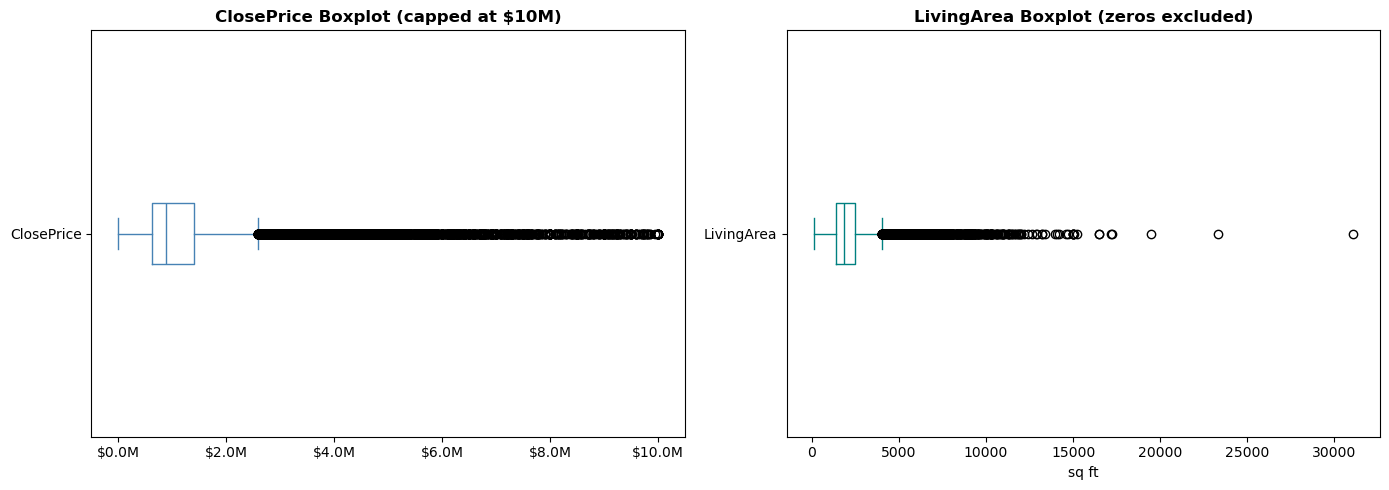

In [48]:
# ── Box plots to visualise extreme tails ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ClosePrice — with and without ultra-luxury
df[df['ClosePrice'] <= 10_000_000]['ClosePrice'].plot(
    kind='box', ax=axes[0], vert=False, color='steelblue'
)
axes[0].set_title('ClosePrice Boxplot (capped at $10M)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# LivingArea — after removing zeros
df[df['LivingArea'] > 0]['LivingArea'].plot(
    kind='box', ax=axes[1], vert=False, color='teal'
)
axes[1].set_title('LivingArea Boxplot (zeros excluded)', fontweight='bold')
axes[1].set_xlabel('sq ft')

plt.tight_layout()
plt.show()

---
## 15. DOM vs Sale-to-List Ratio

Low DOM often signals competing offers — which drives ClosePrice above asking.
High DOM often correlates with price reductions and below-asking closes.
This relationship, if strong, makes `DaysOnMarket` a valuable model feature.

In [49]:
# Bin DOM into interpretable categories per Trestle/MLS conventions
dom_bins   = [-1, 7, 30, 60, 180, 10000]
dom_labels = ['Very Low (1-7d)', 'Low (8-30d)', 'Average (31-60d)',
              'High (61-180d)', 'Very High (180d+)']

df['DOM_Category'] = pd.cut(
    df['DaysOnMarket'], bins=dom_bins, labels=dom_labels
)

dom_stl = (
    df.groupby('DOM_Category', observed=True)
    .agg(
        count=('ClosePrice', 'count'),
        median_price=('ClosePrice', 'median'),
        median_stl=('SaleToListRatio', 'median'),
        pct_above_asking=('SaleToListRatio', lambda x: (x > 1.0).mean() * 100)
    )
    .reset_index()
)

print('DOM Category breakdown:')
display(dom_stl)

DOM Category breakdown:


,DOM_Category,count,median_price,median_stl,pct_above_asking
0,Very Low (1-7d),17212,950000.0,1.007092,56.960260
1,Low (8-30d),26349,930000.0,1.000000,48.297848
2,Average (31-60d),11962,830000.0,0.987740,23.608092
3,High (61-180d),13655,800000.0,0.979899,16.389601
4,Very High (180d+),2282,755000.0,0.969211,11.787905


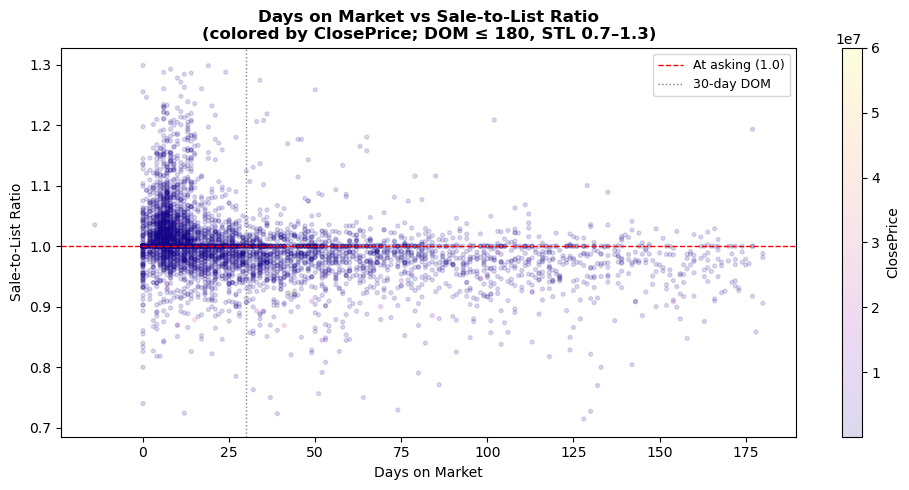

In [50]:
# Scatter: DOM vs SaleToListRatio (sampled for performance)
dom_sample = df[
    (df['DaysOnMarket'] <= 180) &
    (df['SaleToListRatio'] >= 0.7) &
    (df['SaleToListRatio'] <= 1.3)
].sample(min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    dom_sample['DaysOnMarket'], dom_sample['SaleToListRatio'],
    alpha=0.15, s=8,
    c=dom_sample['ClosePrice'], cmap='plasma'
)
ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='At asking (1.0)')
ax.axvline(30, color='gray', linestyle=':', linewidth=1, label='30-day DOM')
plt.colorbar(sc, ax=ax, label='ClosePrice')
ax.set_title('Days on Market vs Sale-to-List Ratio\n'
             '(colored by ClosePrice; DOM ≤ 180, STL 0.7–1.3)',
             fontweight='bold')
ax.set_xlabel('Days on Market')
ax.set_ylabel('Sale-to-List Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

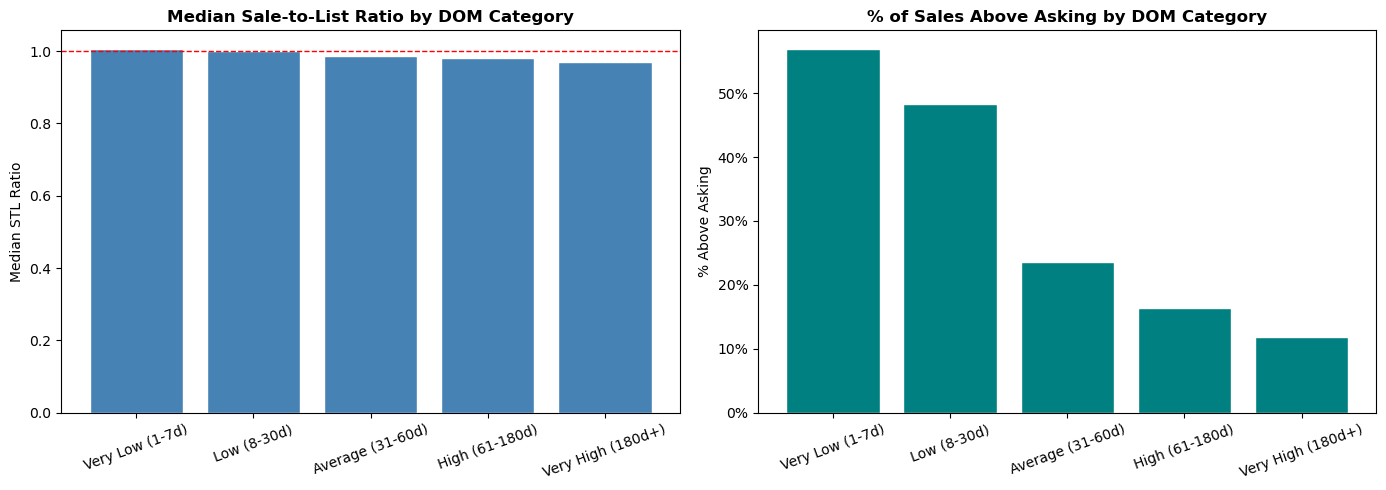

In [51]:
# Median Sale-to-List Ratio by DOM category — bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dom_stl['DOM_Category'], dom_stl['median_stl'],
            color='steelblue', edgecolor='white')
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Median Sale-to-List Ratio by DOM Category', fontweight='bold')
axes[0].set_ylabel('Median STL Ratio')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(dom_stl['DOM_Category'], dom_stl['pct_above_asking'],
            color='teal', edgecolor='white')
axes[1].set_title('% of Sales Above Asking by DOM Category', fontweight='bold')
axes[1].set_ylabel('% Above Asking')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

---
## 16. New Construction vs Resale

`NewConstructionYN` (Boolean) splits the market into two structurally different segments.
New construction sells at a premium and may have different DOM and sale-to-list patterns.
This comparison determines whether it warrants separate treatment in the model.

In [52]:
# Treat NaN as False (not new construction) per imputation plan
df['IsNewConstruction'] = df['NewConstructionYN'].fillna(False)

nc_stats = (
    df.groupby('IsNewConstruction')
    .agg(
        count=('ClosePrice', 'count'),
        median_price=('ClosePrice', 'median'),
        mean_price=('ClosePrice', 'mean'),
        median_ppsf=('PricePerSqFt', 'median'),
        median_living_area=('LivingArea', 'median'),
        median_dom=('DaysOnMarket', 'median'),
        median_stl=('SaleToListRatio', 'median'),
        median_year_built=('YearBuilt', 'median')
    )
    .rename(index={False: 'Resale', True: 'New Construction'})
)

print('New Construction vs Resale comparison:')
display(nc_stats)

price_premium = nc_stats.loc['New Construction', 'median_price'] - nc_stats.loc['Resale', 'median_price']
print(f'\nNew construction median price premium: ${price_premium:,.0f}')

New Construction vs Resale comparison:


/var/folders/_t/ms_9wggj1s1d3vr5j_zzp07c0000gn/T/ipykernel_78628/1204602638.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['IsNewConstruction'] = df['NewConstructionYN'].fillna(False)


,count,median_price,mean_price,median_ppsf,median_living_area,median_dom,median_stl,median_year_built
IsNewConstruction,,,,,,,,
Resale,68912,899900.0,1.345770e+06,534.351145,1806.0,19.0,1.0,1975.0
New Construction,2554,665115.0,1.182165e+06,310.225747,2194.0,40.0,1.0,2025.0



New construction median price premium: $-234,785


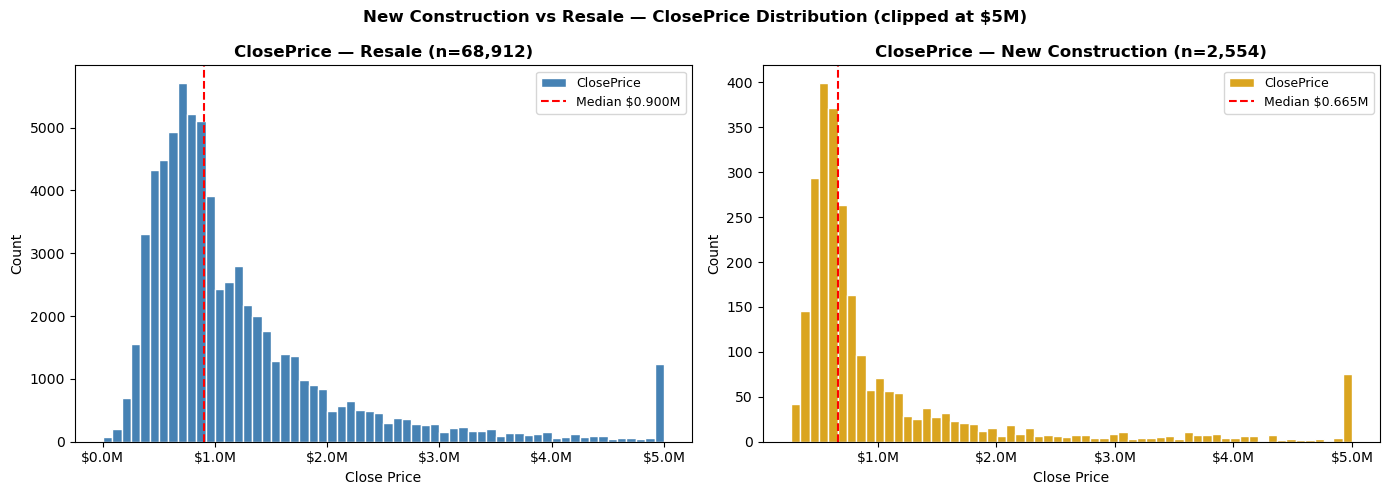

In [53]:
# Side-by-side ClosePrice distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, grp) in zip(axes, df.groupby('IsNewConstruction')):
    name = 'New Construction' if label else 'Resale'
    grp['ClosePrice'].clip(upper=5_000_000).plot(
        kind='hist', bins=60, ax=ax,
        color='goldenrod' if label else 'steelblue',
        edgecolor='white'
    )
    ax.axvline(grp['ClosePrice'].median(), color='red', linestyle='--',
               linewidth=1.5, label=f'Median ${grp["ClosePrice"].median()/1e6:.3f}M')
    ax.set_title(f'ClosePrice — {name} (n={len(grp):,})', fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
    ax.set_xlabel('Close Price')
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('New Construction vs Resale — ClosePrice Distribution (clipped at $5M)',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 17. HOA Fee Distribution & Price Impact

`AssociationFee` (Decimal 14.2) — 28.6% null, treated as no HOA.
HOA communities often include shared amenities that push prices up,
but recurring fees also reduce buyer purchasing power. This analysis
determines whether HOA presence and fee level belong in the model.

In [54]:
# Normalise AssociationFee to monthly equivalent
# AssociationFeeFrequency Enum: Monthly, Quarterly, SemiAnnually, Annually
freq_to_monthly = {
    'Monthly': 1,
    'Quarterly': 1/3,
    'Semi-Annually': 1/6,
    'Annually': 1/12,
}

df['MonthlyHOA'] = (
    df['AssociationFee'].fillna(0) *
    df['AssociationFeeFrequency'].map(freq_to_monthly).fillna(1)  # assume Monthly if unknown
)

df['HasHOA'] = df['AssociationFee'].notna() & (df['AssociationFee'] > 0)

print(f'Properties with HOA: {df["HasHOA"].sum():,} ({df["HasHOA"].mean()*100:.1f}%)')
print(f'Properties without HOA: {(~df["HasHOA"]).sum():,}')
print()
print('Monthly HOA fee summary (HOA properties only):')
print(df[df['HasHOA']]['MonthlyHOA'].describe())

Properties with HOA: 18,713 (26.2%)
Properties without HOA: 52,753

Monthly HOA fee summary (HOA properties only):
count    18713.000000
mean       235.925724
std        274.427669
min          0.012500
25%         99.000000
50%        174.000000
75%        297.000000
max       8244.000000
Name: MonthlyHOA, dtype: float64


,count,median_price,median_ppsf,median_living_area
HasHOA,,,,
No HOA,52753,871000.0,550.081493,1691.0
Has HOA,18713,950000.0,456.162959,2223.0


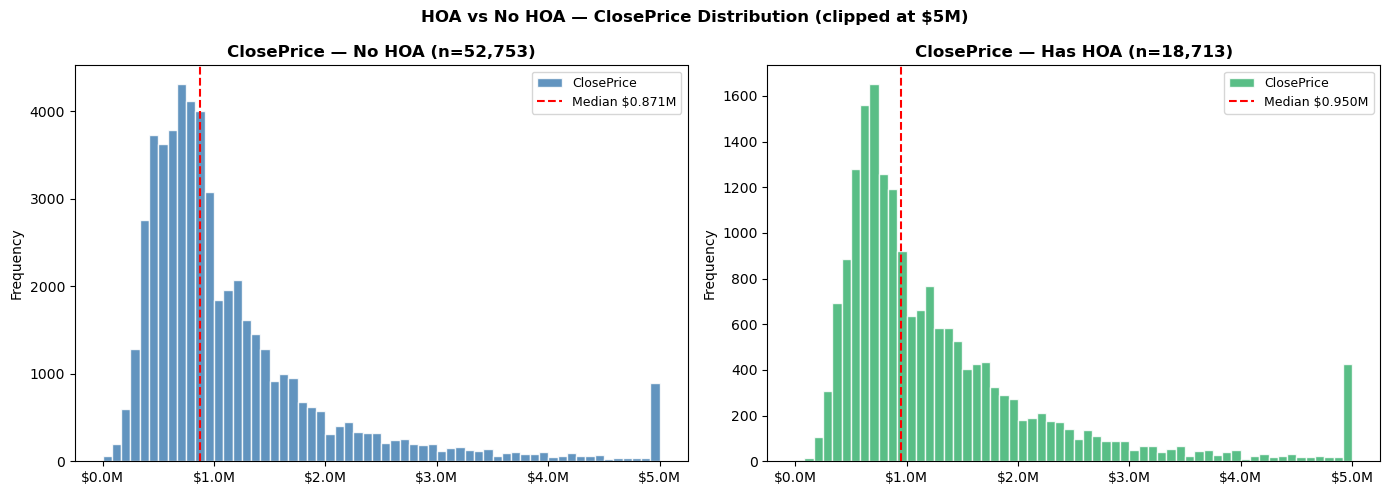

In [55]:
# HOA vs non-HOA ClosePrice comparison
hoa_stats = (
    df.groupby('HasHOA')
    .agg(
        count=('ClosePrice', 'count'),
        median_price=('ClosePrice', 'median'),
        median_ppsf=('PricePerSqFt', 'median'),
        median_living_area=('LivingArea', 'median')
    )
    .rename(index={False: 'No HOA', True: 'Has HOA'})
)
display(hoa_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ClosePrice by HOA status
for ax, (has_hoa, grp) in zip(axes, df.groupby('HasHOA')):
    label = 'Has HOA' if has_hoa else 'No HOA'
    grp['ClosePrice'].clip(upper=5_000_000).plot(
        kind='hist', bins=60, ax=ax,
        color='mediumseagreen' if has_hoa else 'steelblue',
        edgecolor='white', alpha=0.85
    )
    ax.axvline(grp['ClosePrice'].median(), color='red', linestyle='--',
               linewidth=1.5, label=f'Median ${grp["ClosePrice"].median()/1e6:.3f}M')
    ax.set_title(f'ClosePrice — {label} (n={len(grp):,})', fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
    ax.legend(fontsize=9)

plt.suptitle('HOA vs No HOA — ClosePrice Distribution (clipped at $5M)', fontweight='bold')
plt.tight_layout()
plt.show()

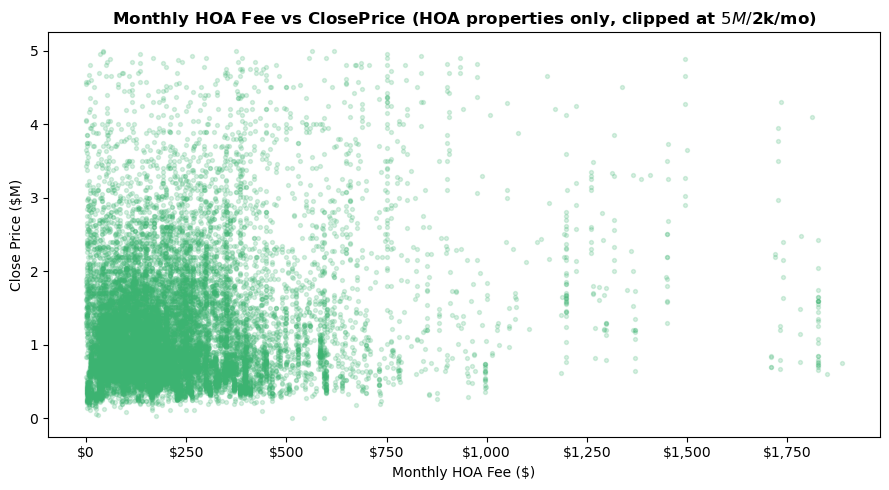

In [56]:
# Monthly HOA fee vs ClosePrice (HOA properties only)
hoa_only = df[df['HasHOA'] & (df['MonthlyHOA'] < 2000) & (df['ClosePrice'] < 5_000_000)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(hoa_only['MonthlyHOA'], hoa_only['ClosePrice']/1e6,
           alpha=0.2, s=8, color='mediumseagreen')
ax.set_title('Monthly HOA Fee vs ClosePrice (HOA properties only, clipped at $5M / $2k/mo)',
             fontweight='bold')
ax.set_xlabel('Monthly HOA Fee ($)')
ax.set_ylabel('Close Price ($M)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 18. Bedroom / Bathroom Joint Distribution

`BedBathRatio = BedroomsTotal / BathroomsTotalInteger` is a planned engineered feature.
Before engineering it, the joint distribution of bedrooms × bathrooms against ClosePrice
reveals whether the ratio captures meaningful price variation.

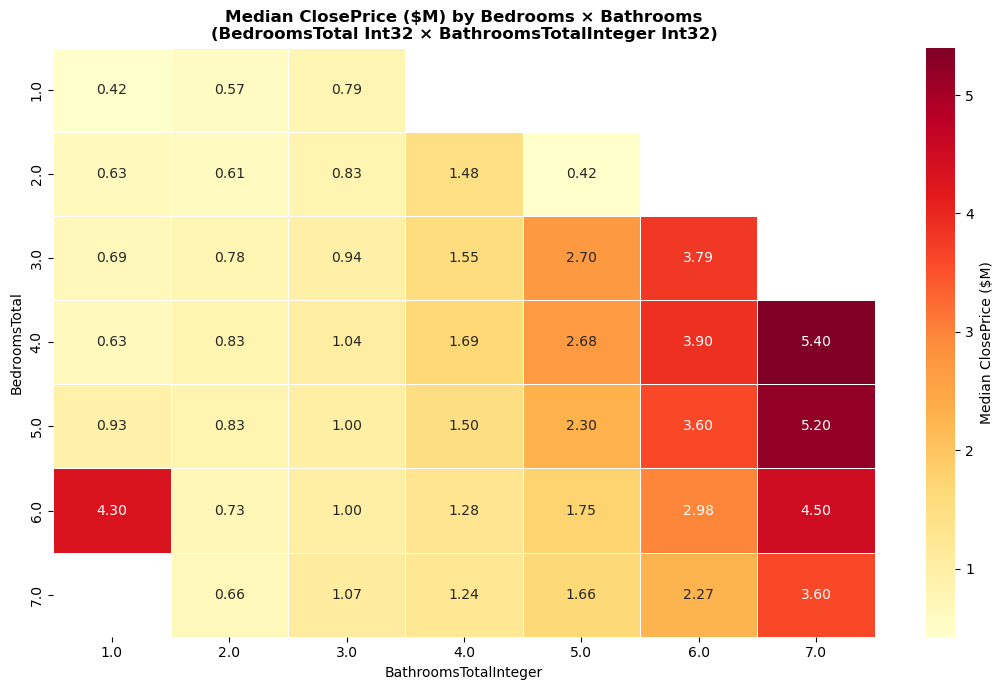

In [57]:
# Heatmap of median ClosePrice by (BedroomsTotal, BathroomsTotalInteger)
pivot = (
    df[
        (df['BedroomsTotal'].between(1, 7)) &
        (df['BathroomsTotalInteger'].between(1, 7))
    ]
    .groupby(['BedroomsTotal', 'BathroomsTotalInteger'])['ClosePrice']
    .median()
    .unstack('BathroomsTotalInteger')
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    pivot / 1e6, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Median ClosePrice ($M)'}
)
ax.set_title('Median ClosePrice ($M) by Bedrooms × Bathrooms\n'
             '(BedroomsTotal Int32 × BathroomsTotalInteger Int32)',
             fontweight='bold')
ax.set_xlabel('BathroomsTotalInteger')
ax.set_ylabel('BedroomsTotal')
plt.tight_layout()
plt.show()

In [58]:
# Engineer BedBathRatio and inspect its relationship with ClosePrice
df['BedBathRatio'] = df['BedroomsTotal'] / df['BathroomsTotalInteger'].replace(0, np.nan)

print('BedBathRatio summary:')
print(df['BedBathRatio'].describe())

# Bin ratio for grouped comparison
ratio_bins   = [0, 1, 1.5, 2, 3, 100]
ratio_labels = ['≤1.0 (bath-heavy)', '1.0–1.5', '1.5–2.0', '2.0–3.0', '>3.0 (bed-heavy)']
df['BedBathCategory'] = pd.cut(df['BedBathRatio'], bins=ratio_bins, labels=ratio_labels)

ratio_stats = (
    df.groupby('BedBathCategory', observed=True)
    .agg(
        count=('ClosePrice', 'count'),
        median_price=('ClosePrice', 'median'),
        median_ppsf=('PricePerSqFt', 'median')
    )
)
print('\nMedian ClosePrice by Bed/Bath Ratio category:')
display(ratio_stats)

BedBathRatio summary:
count    71440.000000
mean         1.452228
std          0.473772
min          0.000000
25%          1.000000
50%          1.500000
75%          1.500000
max          7.500000
Name: BedBathRatio, dtype: float64

Median ClosePrice by Bed/Bath Ratio category:


,count,median_price,median_ppsf
BedBathCategory,,,
≤1.0 (bath-heavy),20363,1175000.0,554.133333
1.0–1.5,33390,875000.0,513.384672
1.5–2.0,14794,800000.0,511.098723
2.0–3.0,2797,710000.0,591.969338
>3.0 (bed-heavy),82,635000.0,461.701128


---
## 19. ZIP Code Reliability Analysis

With 1,675 unique ZIP codes, many will have too few transactions to support reliable
target encoding in Week 3. This section identifies the reliability threshold
and determines how many ZIPs fall below it.

In [59]:
# Transaction count per ZIP
zip_counts = df['PostalCode'].value_counts().reset_index()
zip_counts.columns = ['PostalCode', 'count']

print(f'Total unique ZIP codes: {len(zip_counts):,}')
print()

# Reliability thresholds
for threshold in [5, 10, 20, 30, 50]:
    below = (zip_counts['count'] < threshold).sum()
    pct_zips = below / len(zip_counts) * 100
    pct_rows = zip_counts[zip_counts['count'] < threshold]['count'].sum() / len(df) * 100
    print(f'  < {threshold:>2} transactions: {below:>4} ZIPs ({pct_zips:.1f}% of ZIPs, '
          f'{pct_rows:.1f}% of SFR rows)')

Total unique ZIP codes: 1,675

  <  5 transactions:  655 ZIPs (39.1% of ZIPs, 1.3% of SFR rows)
  < 10 transactions:  788 ZIPs (47.0% of ZIPs, 2.6% of SFR rows)
  < 20 transactions:  914 ZIPs (54.6% of ZIPs, 5.0% of SFR rows)
  < 30 transactions:  984 ZIPs (58.7% of ZIPs, 7.4% of SFR rows)
  < 50 transactions: 1157 ZIPs (69.1% of ZIPs, 16.8% of SFR rows)


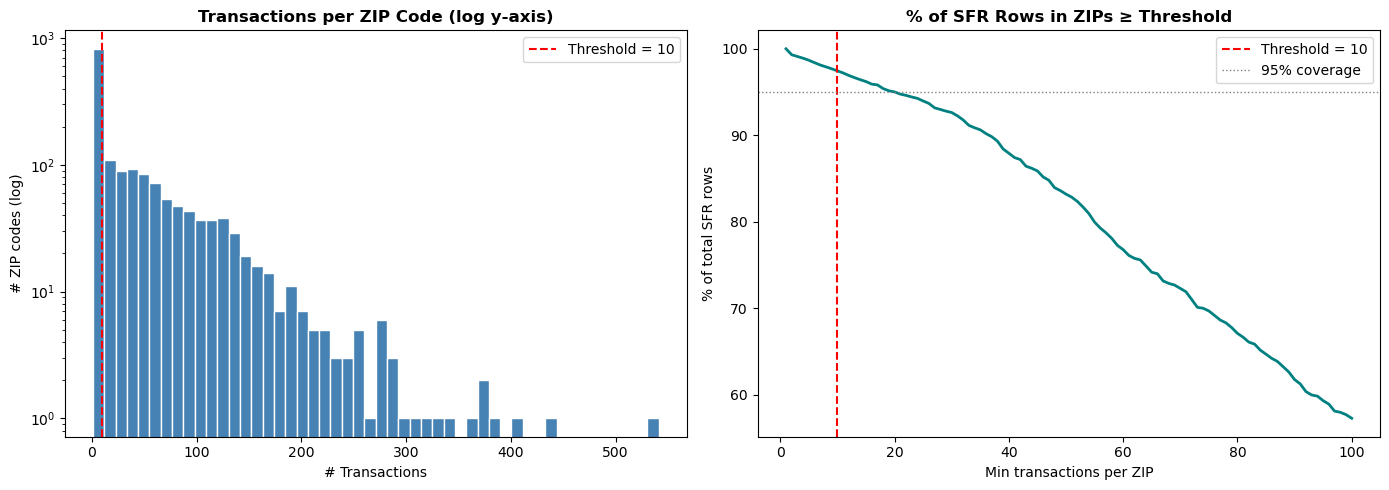

In [60]:
# Distribution of transactions per ZIP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution (log scale for readability)
axes[0].hist(zip_counts['count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].axvline(10, color='red', linestyle='--', linewidth=1.5, label='Threshold = 10')
axes[0].set_title('Transactions per ZIP Code (log y-axis)', fontweight='bold')
axes[0].set_xlabel('# Transactions')
axes[0].set_ylabel('# ZIP codes (log)')
axes[0].legend()

# Cumulative % of rows covered as we increase threshold
thresholds = range(1, 101)
coverage = [
    zip_counts[zip_counts['count'] >= t]['count'].sum() / len(df) * 100
    for t in thresholds
]
axes[1].plot(list(thresholds), coverage, color='teal', linewidth=2)
axes[1].axvline(10, color='red', linestyle='--', linewidth=1.5, label='Threshold = 10')
axes[1].axhline(95, color='gray', linestyle=':', linewidth=1, label='95% coverage')
axes[1].set_title('% of SFR Rows in ZIPs ≥ Threshold', fontweight='bold')
axes[1].set_xlabel('Min transactions per ZIP')
axes[1].set_ylabel('% of total SFR rows')
axes[1].legend()

plt.tight_layout()
plt.show()

In [61]:
# Price variance within ZIPs — ZIPs with high variance may need special handling
zip_stats = (
    df[df['PostalCode'].notna()]
    .groupby('PostalCode')['ClosePrice']
    .agg(count='count', median='median', std='std', cv=lambda x: x.std()/x.mean())
)
# Only ZIPs with ≥ 10 transactions
zip_reliable = zip_stats[zip_stats['count'] >= 10]

print(f'ZIPs with ≥ 10 transactions: {len(zip_reliable):,}')
print('\nCoefficient of variation (price volatility) within ZIP:')
print(zip_reliable['cv'].describe())
print('\nHighest price-variance ZIPs (most heterogeneous):')
print(zip_reliable.sort_values('cv', ascending=False).head(10))

ZIPs with ≥ 10 transactions: 887

Coefficient of variation (price volatility) within ZIP:
count    887.000000
mean       0.438396
std        0.911001
min        0.051892
25%        0.215922
50%        0.302835
75%        0.433576
max       12.438531
Name: cv, dtype: float64

Highest price-variance ZIPs (most heterogeneous):
            count     median           std         cv
PostalCode                                           
92395         224   415000.0  3.150842e+07  12.438531
92056         225   950000.0  4.293634e+07  11.217716
92065         157   825000.0  5.571608e+07  10.446184
92532         132   635000.0  5.347276e+07  10.089584
91911         131   820000.0  5.796231e+07   9.807124
92082         107   925000.0  7.685249e+07   9.071645
92154         108   810000.0  1.020629e+08   6.893017
92057         213   860000.0  6.660443e+06   5.114289
90290          30  1621000.0  3.618465e+07   4.301904
92274          39   300000.0  6.377372e+05   1.642253


---
## 20. Price Reduction Analysis

`PriceReductionYN = ListPrice < OriginalListPrice` signals seller motivation and market
softness at the individual listing level. If price-reduced properties consistently close
below asking and sit on market longer, this binary flag adds predictive value.

In [62]:
# PriceReductionYN was already engineered in Section 7
# Reduction amount and percentage
df['PriceReductionAmt'] = df['OriginalListPrice'] - df['ListPrice']
df['PriceReductionPct'] = (df['PriceReductionAmt'] / df['OriginalListPrice']) * 100

reduced    = df[df['PriceReductionYN'] == True]
not_reduced = df[df['PriceReductionYN'] == False]

print(f'Price-reduced listings  : {len(reduced):,} ({len(reduced)/len(df)*100:.1f}%)')
print(f'Not reduced             : {len(not_reduced):,}')
print()
print('Reduction amount summary (reduced listings only):')
print(reduced['PriceReductionAmt'].describe().apply(lambda x: f'${x:,.0f}'))
print()
print('Reduction % summary:')
print(reduced['PriceReductionPct'].describe())

Price-reduced listings  : 19,920 (27.9%)
Not reduced             : 51,546

Reduction amount summary (reduced listings only):
count           $19,920
mean           $423,735
std         $15,509,227
min                  $1
25%             $20,000
50%             $45,000
75%            $100,000
max      $1,301,000,001
Name: PriceReductionAmt, dtype: object

Reduction % summary:
count    19920.000000
mean         6.719154
std          7.279040
min          0.000013
25%          2.779322
50%          4.879239
75%          8.347245
max         99.923195
Name: PriceReductionPct, dtype: float64


In [63]:
# Compare reduced vs not-reduced on key metrics
comparison = (
    df.groupby('PriceReductionYN')
    .agg(
        count=('ClosePrice', 'count'),
        median_close_price=('ClosePrice', 'median'),
        median_stl=('SaleToListRatio', 'median'),
        pct_above_asking=('SaleToListRatio', lambda x: (x > 1.0).mean() * 100),
        median_dom=('DaysOnMarket', 'median'),
        median_ppsf=('PricePerSqFt', 'median')
    )
    .rename(index={False: 'No Reduction', True: 'Price Reduced'})
)
print('Price-reduced vs not-reduced comparison:')
display(comparison)

Price-reduced vs not-reduced comparison:


,count,median_close_price,median_stl,pct_above_asking,median_dom,median_ppsf
PriceReductionYN,,,,,,
No Reduction,51546,927574.0,1.000000,45.999690,12.0,560.772340
Price Reduced,19920,795000.0,0.985714,20.843373,74.0,436.538628


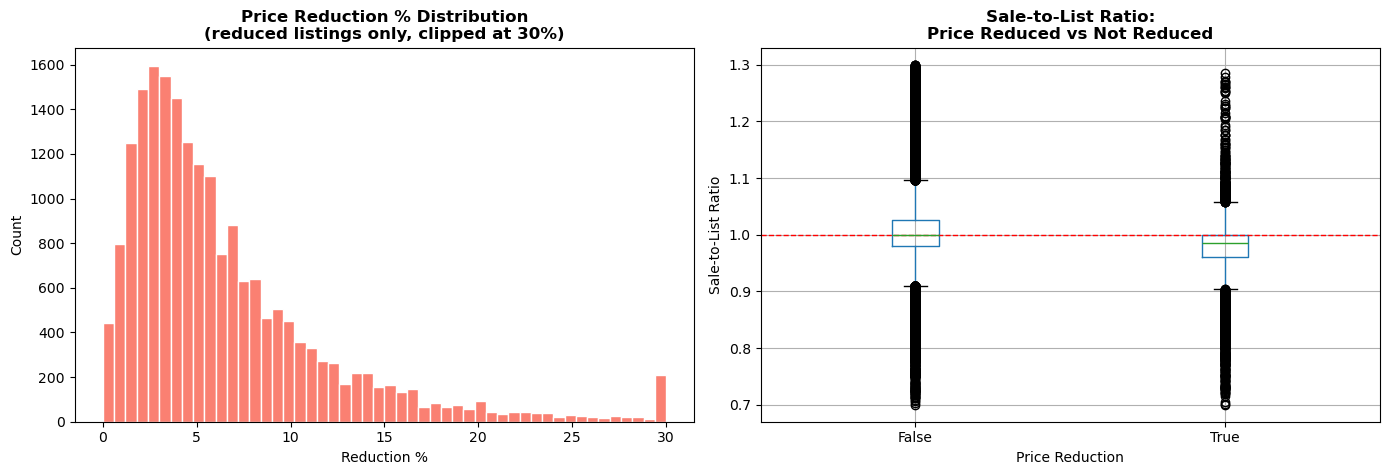

In [64]:
# Distribution of reduction percentage (reduced listings only)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

reduced['PriceReductionPct'].clip(upper=30).plot(
    kind='hist', bins=50, ax=axes[0], color='salmon', edgecolor='white'
)
axes[0].set_title('Price Reduction % Distribution\n(reduced listings only, clipped at 30%)',
                  fontweight='bold')
axes[0].set_xlabel('Reduction %')
axes[0].set_ylabel('Count')

# STL ratio: reduced vs not reduced
df[(df['SaleToListRatio'].between(0.7, 1.3))].boxplot(
    column='SaleToListRatio', by='PriceReductionYN', ax=axes[1]
)
axes[1].set_title('Sale-to-List Ratio:\nPrice Reduced vs Not Reduced', fontweight='bold')
axes[1].set_xlabel('Price Reduction')
axes[1].set_ylabel('Sale-to-List Ratio')
axes[1].axhline(1.0, color='red', linestyle='--', linewidth=1)
plt.suptitle('')  # remove default pandas boxplot title

plt.tight_layout()
plt.show()

---
## 21. Flooring Type vs ClosePrice

`Flooring` is a multi-value Flooring Enum with ~235 unique combinations.
Exploding to individual types and comparing median ClosePrice per type
reveals which binary flooring flags are worth keeping as model features.

In [65]:
# Explode multi-value Flooring enum to individual types
flooring_exploded = (
    df[['ListingKey', 'ClosePrice', 'PricePerSqFt', 'Flooring']]
    .dropna(subset=['Flooring'])
    .copy()
)
flooring_exploded['FlooringType'] = flooring_exploded['Flooring'].str.split(',')
flooring_exploded = flooring_exploded.explode('FlooringType')
flooring_exploded['FlooringType'] = flooring_exploded['FlooringType'].str.strip()

# Frequency of each flooring type
flooring_freq = flooring_exploded['FlooringType'].value_counts()
print('Flooring type frequencies (individual types):')
print(flooring_freq.to_string())

Flooring type frequencies (individual types):
FlooringType
Tile          22864
Carpet        20345
Wood          17399
Laminate      12597
Vinyl          8294
Stone          2016
SeeRemarks     1649
Concrete        661
Bamboo          259
Brick            72


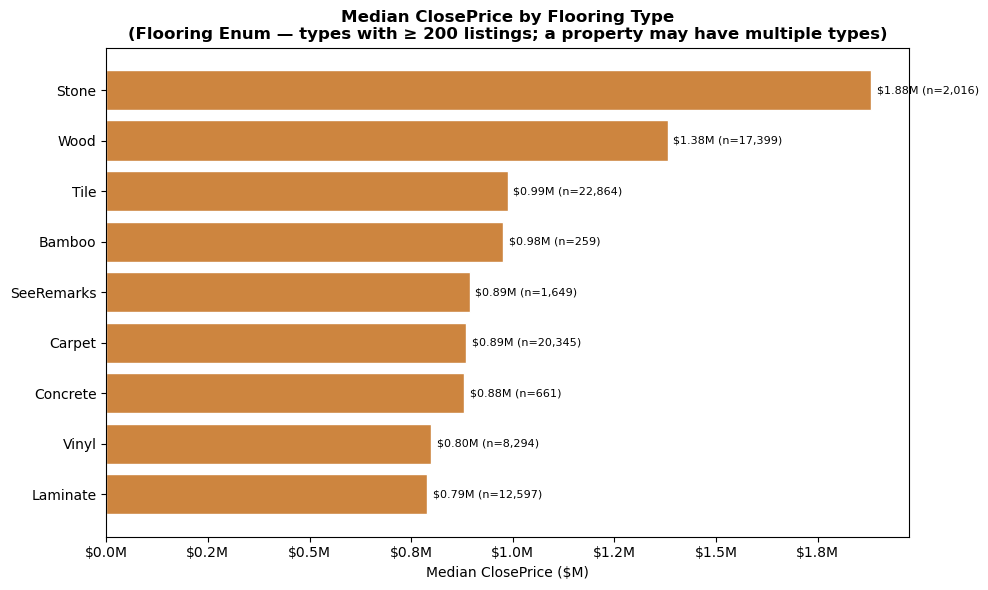


Flooring types that will become binary features (≥ 200 listings): ['Tile', 'Carpet', 'Wood', 'Laminate', 'Vinyl', 'Stone', 'SeeRemarks', 'Concrete', 'Bamboo']


In [66]:
# Median ClosePrice per flooring type (types with ≥ 200 listings)
flooring_price = (
    flooring_exploded
    .groupby('FlooringType')
    .agg(
        count=('ClosePrice', 'count'),
        median_price=('ClosePrice', 'median'),
        median_ppsf=('PricePerSqFt', 'median')
    )
    .query('count >= 200')
    .sort_values('median_price', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(flooring_price.index, flooring_price['median_price']/1e6,
               color='peru', edgecolor='white')
ax.bar_label(bars, labels=[f'${v:.2f}M (n={n:,})'
                            for v, n in zip(flooring_price['median_price']/1e6,
                                            flooring_price['count'])],
             padding=4, fontsize=8)
ax.set_title('Median ClosePrice by Flooring Type\n'
             '(Flooring Enum — types with ≥ 200 listings; a property may have multiple types)',
             fontweight='bold')
ax.set_xlabel('Median ClosePrice ($M)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:.1f}M'))
plt.tight_layout()
plt.show()

# Identify top flooring types to create binary flags for
TOP_FLOORING_TYPES = flooring_freq[flooring_freq >= 200].index.tolist()
print(f'\nFlooring types that will become binary features (≥ 200 listings): {TOP_FLOORING_TYPES}')

# Create binary flags now for reference
for ft in TOP_FLOORING_TYPES:
    col = f'Flooring_{ft.replace(" ", "_").replace("/", "_")}'
    df[col] = df['Flooring'].fillna('').str.contains(ft, case=False)

---
## 22. EDA Summary & Week 3 Preprocessing Plan

### Dataset Snapshot

| Item | Value |
|---|---|
| Total rows (all PropertyTypes) | 143,492 |
| Rows after SFR filter | 71,466 |
| Date range (CloseDate) | Nov 2025 – May 2026 |
| Trestle columns | 78 |
| Columns 100% null in this extract | 8 (drop) |
| ClosePrice median | $889,000 |
| ClosePrice p1–p99 | $230k – $6.5M |
| Median LivingArea | 1,824 sq ft |
| Median DaysOnMarket | See output above |
| Median YearBuilt | 1977 (median PropertyAge ~49 yrs) |

### Fields to DROP (from modelling)

| Field | Reason |
|---|---|
| `AboveGradeFinishedArea` | 100% null in this extract |
| `BelowGradeFinishedArea` | 99.3% null |
| `BuildingAreaTotal` | 93.3% null |
| `TaxAnnualAmount` | 100% null |
| `CoveredSpaces` | 100% null |
| `FireplacesTotal` | 100% null (use `FireplaceYN` instead) |
| `BusinessType` | 100% null — not applicable to SFR |
| `ElementarySchoolDistrict` | 100% null |
| `MiddleOrJuniorSchoolDistrict` | 100% null |
| `WaterfrontYN` | 99.9% null |
| `BasementYN` | 97.6% null |
| `ElementarySchool` | 87.3% null |
| `MiddleOrJuniorSchool` | 87.2% null |
| `HighSchool` | 83.2% null (use `HighSchoolDistrict`) |
| `LotSizeAcres` / `LotSizeArea` | Redundant with `LotSizeSquareFeet` |
| `LotSizeDimensions` | Freeform String 150 — not modelable |
| `MainLevelBedrooms` | 39.0% null; overlaps `BedroomsTotal` |

### Imputation Plan

| Field | Strategy |
|---|---|
| `LotSizeSquareFeet` (1.7% null) | Impute with ZIP-level median |
| `GarageSpaces` (3.9% null) | Impute 0 — no garage |
| `Stories` (10.5% null) | Impute with mode (=1) or derive from `Levels_primary` |
| `PoolPrivateYN` (7.8% null) | Impute False |
| `ViewYN` (8.7% null) | Impute False |
| `AttachedGarageYN` (12.2% null) | Impute False |
| `NewConstructionYN` (7.6% null) | Impute False |
| `AssociationFee` (28.6% null) | Impute 0 — no HOA |
| `AssociationFeeFrequency` (74% null) | Impute 'None' — normalize fee to monthly |
| `HighSchoolDistrict` (26.9% null) | Supplement with spatial join (Week 6) |
| `Flooring` (36.3% null) | Create binary flags for top types; null → 'Unknown' |

### Feature Engineering Plan (Week 6)

| Feature | Formula | Source Fields |
|---|---|---|
| `PropertyAge` | `2026 - YearBuilt` | `YearBuilt` (Int32) |
| `BedBathRatio` | `BedroomsTotal / BathroomsTotalInteger` | Both Int32 |
| `PricePerSqFt` | `ClosePrice / LivingArea` (exploratory only) | Both Decimal 14.2 |
| `SaleToListRatio` | `ClosePrice / ListPrice` | Both Decimal 14.2 |
| `PriceReductionYN` | `ListPrice < OriginalListPrice` | Both Decimal 14.2 |
| `MonthlyHOA` | Normalize `AssociationFee` by `AssociationFeeFrequency` | Decimal + Enum |
| `Levels_primary` | First value from `Levels` enum (One/Two/ThreeOrMore/MultiSplit) | Levels Enum |
| `Flooring_*` | Binary flags: `Flooring_Wood`, `Flooring_Tile`, etc. | Flooring Enum |

### Outlier Flags (to resolve in Week 3)

| Flag | Count | Action |
|---|---|---|
| `ClosePrice < $10k` | 4 | Drop — likely data entry errors |
| `ClosePrice > $10M` | 288 | Review; may cap at 99th percentile or keep with log transform |
| `LivingArea == 0` | 20 | Drop — structural data error |
| `BedroomsTotal == 0` | 31 | Review individually |

### Train / Test Split (Week 3)
- **Test set:** May 2026 (`CRMLSSold202605.csv`) — most recent month, ~12,024 SFR rows
- **Training set:** Nov 2025 – Apr 2026 — ~59,442 SFR rows
- Window length (how many months to include) is a tunable hyperparameter — experiment in Week 4+

### To-Do Before Running Week 3
- [ ] Drop all 100%-null columns listed above
- [ ] Drop 4 rows with `ClosePrice < $10k` and 20 rows with `LivingArea == 0`
- [ ] Apply all imputation strategies in the table above
- [ ] Engineer all features in the engineering plan
- [ ] Encode `PostalCode`, `CountyOrParish`, `City` (target encoding or ordinal)
- [ ] Encode `Levels_primary` as ordinal (One=1, Two=2, ThreeOrMore=3, MultiSplit=2)
- [ ] Save cleaned dataset to `data/cleaned/sfr_cleaned.csv`